# round5_analysis.ipynb
---

# Round 5: Pairs Trading — Exploratory Research Log

> ⚠️ **This notebook is intentionally unpolished.** It documents a live search for a lead-lag signal that ultimately yielded no robust out-of-sample result. The analytical post-mortem — what went wrong and why — is in [`round5.md`](../round5.md).

---

## Context

Round 5 introduced a large universe of ~40+ products across 10 sector groups (GALAXY_SOUNDS, MICROCHIP, SNACKPACK, SLEEP_POD, TRANSLATOR, etc.). The competition organizers hinted at a **lead-lag relationship** between assets — and that hint became the central anchoring point of this research.

The plan: systematically screen for cross-asset predictive structure using OBI (Order Book Imbalance) and price correlation, then build a pairs trading signal on whatever lead-lag relationship emerged.

**What actually happened:** Every candidate signal that looked promising in-sample on Day 2 failed to generalize. This notebook is the record of that process.

---

## Phase 1: Exploratory Data Analysis
*Goal: Understand the universe before committing to any signal hypothesis.*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'grid.color': '#21262d', 'font.size': 9,
})

DATA_DIR = Path('.')
frames = []
files = sorted(list(DATA_DIR.glob('../_source_data/prices_round_5_day_*.csv')))
if not files:
    print("Warning: No price files found in current directory.")
else:
    for f in files:
        frames.append(pd.read_csv(f, sep=';'))
    prices = pd.concat(frames, ignore_index=True)

    prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']
    prices['obi'] = (prices['bid_volume_1'] - prices['ask_volume_1']) / (prices['bid_volume_1'] + prices['ask_volume_1'])
    prices['global_ts'] = prices['day'] * 1_000_000 + prices['timestamp']

    CATEGORIES = {
        'GALAXY_SOUNDS': [], 'MICROCHIP': [], 'OXYGEN_SHAKE': [],
        'PANEL': [], 'PEBBLES': [], 'ROBOT': [],
        'SLEEP_POD': [], 'SNACKPACK': [], 'TRANSLATOR': [], 'UV_VISOR': []
    }
    for p in sorted(prices['product'].unique()):
        for cat in CATEGORIES:
            if p.startswith(cat):
                CATEGORIES[cat].append(p)
                break

    def get_group(product):
        for cat in CATEGORIES:
            if product.startswith(cat):
                return cat
        return 'OTHER'

    prices['group'] = prices['product'].apply(get_group)
    prices['variant'] = prices.apply(lambda r: r['product'].replace(r['group']+'_',''), axis=1)

    print(f'Loaded {len(prices):,} rows, {prices["product"].nunique()} products')
    for cat, prods in sorted(CATEGORIES.items()):
        if prods:
            print(f'  {cat}: {[p.replace(cat+"_","") for p in prods]}')

c:\Users\dhko23\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Loaded 1,500,000 rows, 50 products
  GALAXY_SOUNDS: ['BLACK_HOLES', 'DARK_MATTER', 'PLANETARY_RINGS', 'SOLAR_FLAMES', 'SOLAR_WINDS']
  MICROCHIP: ['CIRCLE', 'OVAL', 'RECTANGLE', 'SQUARE', 'TRIANGLE']
  OXYGEN_SHAKE: ['CHOCOLATE', 'EVENING_BREATH', 'GARLIC', 'MINT', 'MORNING_BREATH']
  PANEL: ['1X2', '1X4', '2X2', '2X4', '4X4']
  PEBBLES: ['L', 'M', 'S', 'XL', 'XS']
  ROBOT: ['DISHES', 'IRONING', 'LAUNDRY', 'MOPPING', 'VACUUMING']
  SLEEP_POD: ['COTTON', 'LAMB_WOOL', 'NYLON', 'POLYESTER', 'SUEDE']
  SNACKPACK: ['CHOCOLATE', 'PISTACHIO', 'RASPBERRY', 'STRAWBERRY', 'VANILLA']
  TRANSLATOR: ['ASTRO_BLACK', 'ECLIPSE_CHARCOAL', 'GRAPHITE_MIST', 'SPACE_GRAY', 'VOID_BLUE']
  UV_VISOR: ['AMBER', 'MAGENTA', 'ORANGE', 'RED', 'YELLOW']


### Step 1–3: Spread, OBI, and Price Distributions

First-pass data audit across all 10 sector groups. Spread and OBI distributions establish the baseline friction cost — any signal needs to generate edge large enough to survive these spreads.

**What we're looking for:** Sectors with tight spreads (tradable) and non-zero mean OBI (potential directional bias).


## 1. Spread & OBI Summary Table (Quantification)

In [2]:
# ── Product-level quantitative summary ──
if 'prices' in locals():
    stats = prices.groupby(['group','product','variant']).agg(
        spread_mean  = ('spread', 'mean'),
        spread_med   = ('spread', 'median'),
        spread_std   = ('spread', 'std'),
        obi_mean     = ('obi', 'mean'),
        obi_std      = ('obi', 'std'),
        mid_mean     = ('mid_price', 'mean'),
        mid_std      = ('mid_price', 'std'),
        mid_min      = ('mid_price', 'min'),
        mid_max      = ('mid_price', 'max'),
).round(4)
    stats['spread_bps'] = (stats['spread_mean'] / stats['mid_mean'] * 10000).round(1)
    display(stats[['spread_mean','spread_med','spread_bps','obi_mean','obi_std','mid_mean','mid_min','mid_max']])

spread_mean  \
group         product                       variant                         
GALAXY_SOUNDS GALAXY_SOUNDS_BLACK_HOLES     BLACK_HOLES           14.5128   
              GALAXY_SOUNDS_DARK_MATTER     DARK_MATTER           13.0508   
              GALAXY_SOUNDS_PLANETARY_RINGS PLANETARY_RINGS       13.6900   
              GALAXY_SOUNDS_SOLAR_FLAMES    SOLAR_FLAMES          14.0715   
              GALAXY_SOUNDS_SOLAR_WINDS     SOLAR_WINDS           13.3013   
MICROCHIP     MICROCHIP_CIRCLE              CIRCLE                 8.2622   
              MICROCHIP_OVAL                OVAL                   7.4498   
              MICROCHIP_RECTANGLE           RECTANGLE              7.8858   
              MICROCHIP_SQUARE              SQUARE                11.7188   
              MICROCHIP_TRIANGLE            TRIANGLE               8.6354   
OXYGEN_SHAKE  OXYGEN_SHAKE_CHOCOLATE        CHOCOLATE             12.1855   
              OXYGEN_SHAKE_EVENING_BREATH   EVENING_BREATH        11.8605   
              OXYGEN_SHAKE_GARLIC           GARLIC                15.0546   
              OXYGEN_SHAKE_MINT             MINT                  12.5936   
              OXYGEN_SHAKE_MORNING_BREATH   MORNING_BREATH        12.7829   
PANEL         PANEL_1X2                     1X2                   11.5098   
              PANEL_1X4                     1X4                    8.3766   
              PANEL_2X2                     2X2                    8.5155   
              PANEL_2X4                     2X4                    9.8405   
              PANEL_4X4                     4X4                    8.7505   
PEBBLES       PEBBLES_L                     L                     13.0205   
              PEBBLES_M                     M                     13.1209   
              PEBBLES_S                     S                     11.5515   
              PEBBLES_XL                    XL                    16.6308   
              PEBBLES_XS                    XS                     9.7449   
ROBOT         ROBOT_DISHES                  DISHES                 7.3503   
              ROBOT_IRONING                 IRONING                6.3929   
              ROBOT_LAUNDRY                 LAUNDRY                7.1651   
              ROBOT_MOPPING                 MOPPING                7.9707   
              ROBOT_VACUUMING               VACUUMING              6.7533   
SLEEP_POD     SLEEP_POD_COTTON              COTTON                10.0502   
              SLEEP_POD_LAMB_WOOL           LAMB_WOOL              9.4001   
              SLEEP_POD_NYLON               NYLON                  8.5647   
              SLEEP_POD_POLYESTER           POLYESTER             10.2957   
              SLEEP_POD_SUEDE               SUEDE                  9.9495   
SNACKPACK     SNACKPACK_CHOCOLATE           CHOCOLATE             16.4712   
              SNACKPACK_PISTACHIO           PISTACHIO             15.9256   
              SNACKPACK_RASPBERRY           RASPBERRY             16.8425   
              SNACKPACK_STRAWBERRY          STRAWBERRY            17.8265   
              SNACKPACK_VANILLA             VANILLA               16.8687   
TRANSLATOR    TRANSLATOR_ASTRO_BLACK        ASTRO_BLACK            8.3664   
              TRANSLATOR_ECLIPSE_CHARCOAL   ECLIPSE_CHARCOAL       8.7004   
              TRANSLATOR_GRAPHITE_MIST      GRAPHITE_MIST          8.9121   
              TRANSLATOR_SPACE_GRAY         SPACE_GRAY             8.4022   
              TRANSLATOR_VOID_BLUE          VOID_BLUE              9.5247   
UV_VISOR      UV_VISOR_AMBER                AMBER                 10.3205   
              UV_VISOR_MAGENTA              MAGENTA               14.0916   
              UV_VISOR_ORANGE               ORANGE                13.2841   
              UV_VISOR_RED                  RED                   14.0394   
              UV_VISOR_YELLOW               YELLOW                13.9100   

                                                         

In [3]:
# ── Group-level summary (sorted by spread) ──
if 'prices' in locals():
    group_stats = prices.groupby('group').agg(
        avg_spread   = ('spread', 'mean'),
        avg_spread_pct = ('spread', lambda x: (x / prices.loc[x.index, 'mid_price']).mean() * 100),
        avg_obi      = ('obi', 'mean'),
        obi_std      = ('obi', 'std'),
        avg_mid      = ('mid_price', 'mean'),
        volatility   = ('mid_price', lambda x: x.pct_change().std() * 100),
).round(4)
    group_stats = group_stats.sort_values('avg_spread')
    print('=== GROUP-LEVEL SUMMARY (sorted by spread) ===')
    display(group_stats)

=== GROUP-LEVEL SUMMARY (sorted by spread) ===


,avg_spread,avg_spread_pct,avg_obi,obi_std,avg_mid,volatility
group,,,,,,
ROBOT,7.1264,0.0731,-0.0001,0.2334,9761.9272,16.2357
TRANSLATOR,8.7812,0.0886,-0.0001,0.1443,9914.8164,10.9082
MICROCHIP,8.7904,0.0894,0.0006,0.1779,9881.6125,36.1575
PANEL,9.3986,0.0966,-0.0002,0.1464,9808.2001,16.1010
SLEEP_POD,9.6520,0.0877,-0.0001,0.1095,11020.7019,13.3518
PEBBLES,12.8137,0.1287,0.0005,0.0932,9999.9879,42.3447
OXYGEN_SHAKE,12.8954,0.1276,-0.0003,0.1185,10118.6523,16.6810
UV_VISOR,13.1291,0.1278,-0.0003,0.1187,10294.1499,24.8302
GALAXY_SOUNDS,13.7253,0.1272,-0.0003,0.1185,10798.0645,10.2574


## 2. Spread Histograms

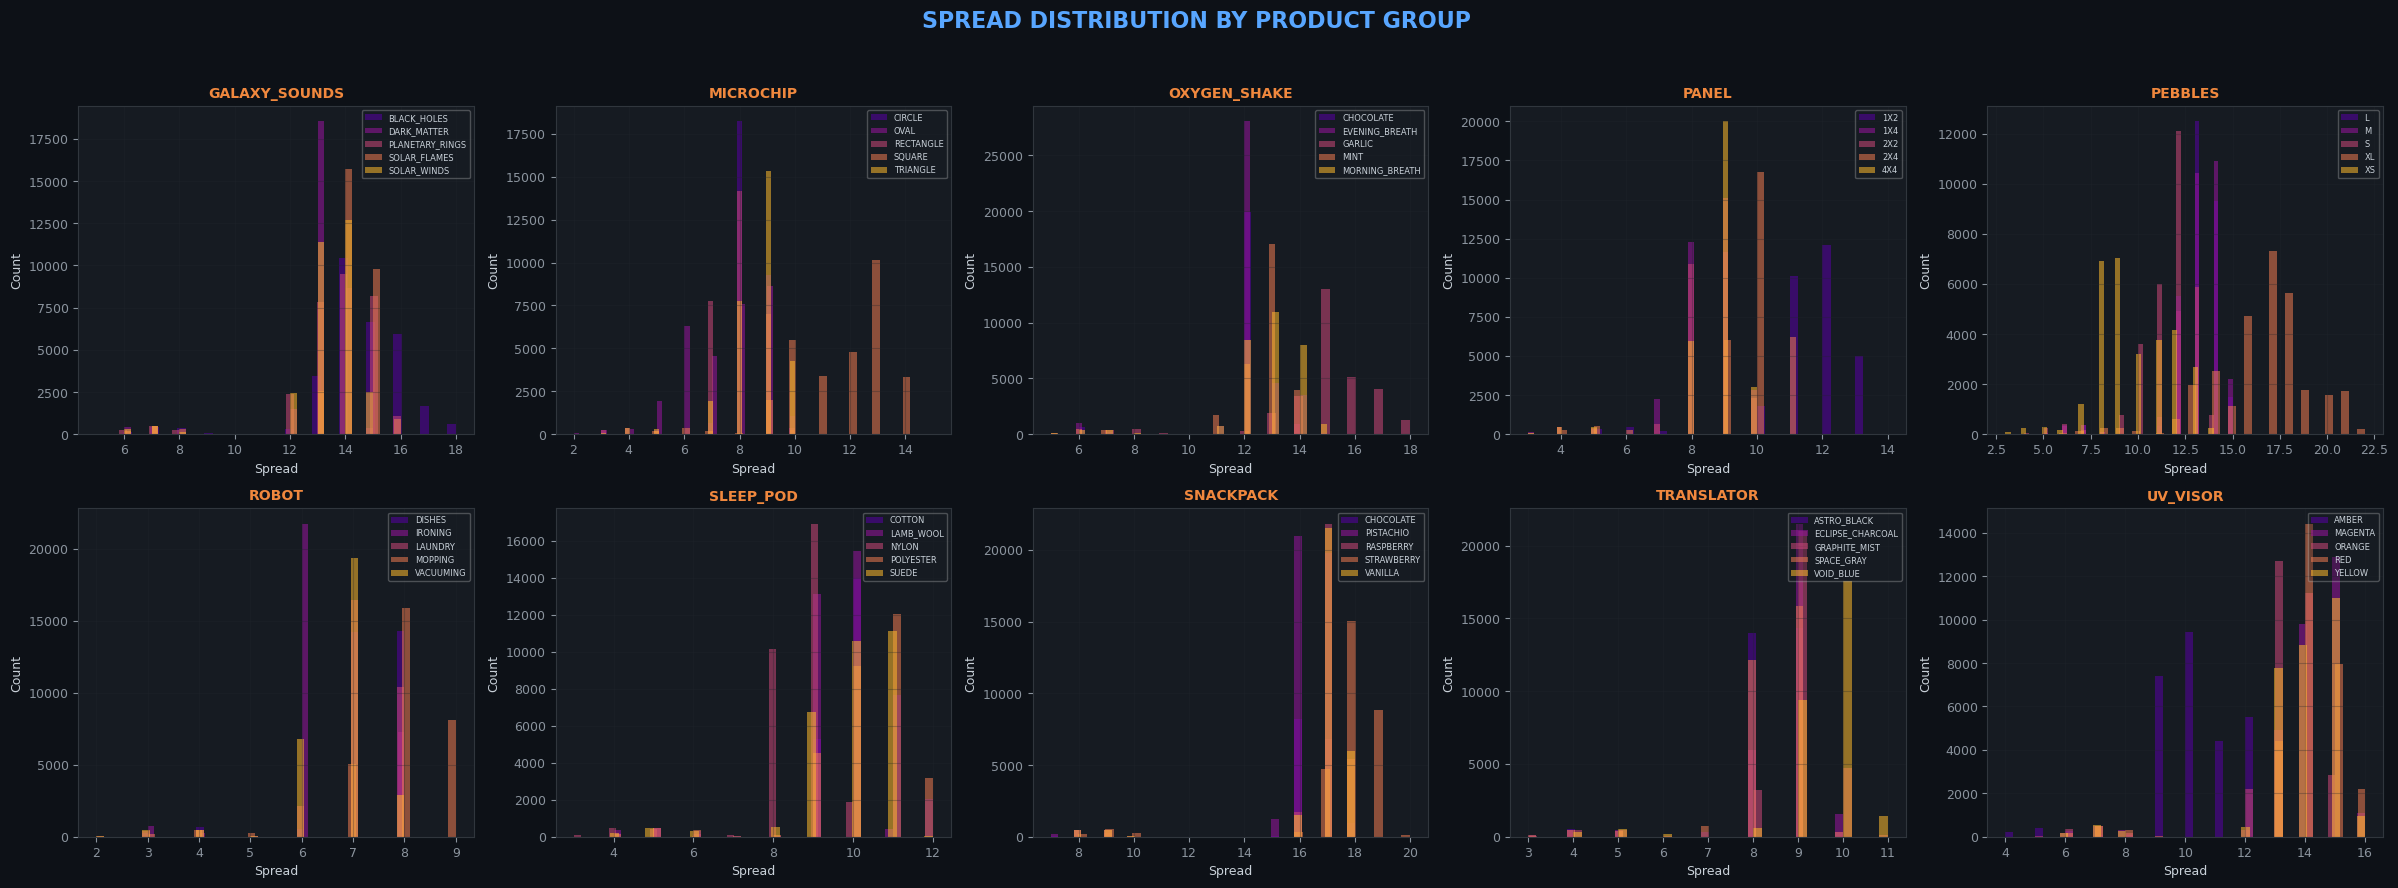

In [4]:
if 'prices' in locals():
    fig, axes = plt.subplots(2, 5, figsize=(24, 9))
    fig.suptitle('SPREAD DISTRIBUTION BY PRODUCT GROUP', fontsize=16, fontweight='bold', color='#58a6ff', y=0.98)
    colors_g = plt.cm.plasma(np.linspace(0.15, 0.85, 5))

    for idx, (cat, prods) in enumerate(sorted(CATEGORIES.items())):
        ax = axes[idx // 5, idx % 5]
        for j, p in enumerate(prods):
            sub = prices[prices['product'] == p]['spread'].dropna()
            ax.hist(sub, bins=40, alpha=0.55, label=p.replace(cat+'_',''), color=colors_g[j % 5], edgecolor='none')
        ax.set_title(cat, fontsize=10, fontweight='bold', color='#f0883e')
        ax.legend(fontsize=6, loc='upper right', framealpha=0.3)
        ax.set_xlabel('Spread'); ax.set_ylabel('Count'); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## 3. OBI Histograms

In [ ]:
if 'prices' in locals():
    fig, axes = plt.subplots(2, 5, figsize=(24, 9))
    fig.suptitle('ORDER BOOK IMBALANCE (OBI) DISTRIBUTION', fontsize=16, fontweight='bold', color='#58a6ff', y=0.98)

    for idx, (cat, prods) in enumerate(sorted(CATEGORIES.items())):
        ax = axes[idx // 5, idx % 5]
        for j, p in enumerate(prods):
            sub = prices[prices['product'] == p]['obi'].dropna()
            ax.hist(sub, bins=40, alpha=0.55, label=p.replace(cat+'_',''), color=colors_g[j % 5], edgecolor='none')
        ax.set_title(cat, fontsize=10, fontweight='bold', color='#f0883e')
        ax.legend(fontsize=6, loc='upper right', framealpha=0.3)
        ax.set_xlabel('OBI'); ax.set_ylabel('Count')
        ax.axvline(0, color='#f85149', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### Step 4–6: Correlation Structure

Return correlation matrix across the full product universe, then broken down intra-group and cross-group.

**Key question:** Are there sector pairs or product pairs with meaningful negative correlation (mean-reversion candidates) or stable co-movement (cointegration candidates)?

> **Finding:** Intra-group correlations were generally high and positive — products within the same sector moved together. Cross-group correlations were close to zero. This ruled out most obvious cross-sector pair trading setups.


## 4. Mid Price Return Correlation Matrix

In [ ]:
if 'prices' in locals():
    pivot = prices.pivot_table(index='global_ts', columns='product', values='mid_price')
    returns = pivot.pct_change().dropna()
    corr = returns.corr()

    sorted_products = []
    for cat in sorted(CATEGORIES.keys()):
        sorted_products.extend(sorted(CATEGORIES[cat]))
    corr = corr.loc[sorted_products, sorted_products]

    short_labels = []
    for p in sorted_products:
        for cat in CATEGORIES:
            if p.startswith(cat):
                short_labels.append(p.replace(cat+'_',''))
                break

    fig, ax = plt.subplots(figsize=(20, 17))
    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(sorted_products)))
    ax.set_yticks(range(len(sorted_products)))
    ax.set_xticklabels(short_labels, rotation=90, fontsize=6)
    ax.set_yticklabels(short_labels, fontsize=6)

    pos = 0
    cat_positions = []
    for cat in sorted(CATEGORIES.keys()):
        n = len(CATEGORIES[cat])
        cat_positions.append((pos, pos+n, cat))
        ax.axhline(pos-0.5, color='#58a6ff', lw=0.8, alpha=0.7)
        ax.axvline(pos-0.5, color='#58a6ff', lw=0.8, alpha=0.7)
        pos += n
    for s, e, cat in cat_positions:
        ax.text(len(sorted_products)+0.5, (s+e)/2-0.5, cat, fontsize=7, color='#f0883e', fontweight='bold', va='center')

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Correlation (returns)', fontsize=11)
    ax.set_title('MID PRICE RETURN CORRELATION MATRIX', fontsize=16, fontweight='bold', color='#58a6ff', pad=15)
    plt.tight_layout()
    plt.show()

## 5. Intra-group Correlation (Quantification)

In [ ]:
if 'prices' in locals() and 'corr' in locals():
    print('='*80)
    print('INTRA-GROUP CORRELATION (within each category)')
    print('='*80)

    for cat in sorted(CATEGORIES.keys()):
        prods = CATEGORIES[cat]
        if not prods: continue
        sub_corr = corr.loc[prods, prods]
        pairs = []
        for i in range(len(prods)):
            for j in range(i+1, len(prods)):
                p1 = prods[i].replace(cat+'_','')
                p2 = prods[j].replace(cat+'_','')
                c = sub_corr.iloc[i, j]
                pairs.append((p1, p2, c))
        pairs.sort(key=lambda x: x[2])
        if pairs:
            avg_corr = np.mean([x[2] for x in pairs])
            print(f'\n▶ {cat}  (avg intra-corr: {avg_corr:.4f})')
            for p1, p2, c in pairs:
                bar = '█' * int(abs(c) * 20)
                color = '🟢' if c > 0.1 else ('🔴' if c < -0.1 else '⚪')
                print(f'  {color} {p1:20s} ↔ {p2:20s}  {c:+.4f}  {bar}')

## 6. Cross-group Correlation (Quantification)

In [ ]:
if 'prices' in locals() and 'returns' in locals():
    group_returns = pd.DataFrame()
    for cat in sorted(CATEGORIES.keys()):
        prods = CATEGORIES[cat]
        if prods:
            group_returns[cat] = returns[prods].mean(axis=1)

    cross_corr = group_returns.corr()

    print('='*80)
    print('CROSS-GROUP CORRELATION MATRIX (group avg returns)')
    print('='*80)
    display(cross_corr.round(4).style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1))

### Step 7–8: Signal Candidate Screening

Systematic scan for pair trading candidates (|corr| > 0.3) and OBI predictive power (corr(OBI_t, return_{t+1})).

> **Finding:** OBI had weak forward predictive power across most products — correlations were small in magnitude and inconsistent across days. No product showed a reliably strong OBI → next-tick return relationship that could survive spread costs.


## 7. Trading Signal Candidates ((quantified))

In [ ]:
if 'prices' in locals() and 'corr' in locals():
    print('='*80)
    print('PAIR TRADING CANDIDATES (|corr| > 0.3 within group, negative = mean-revert pair)')
    print('='*80)

    all_pairs = []
    for cat in sorted(CATEGORIES.keys()):
        prods = CATEGORIES[cat]
        if not prods: continue
        sub_corr = corr.loc[prods, prods]
        for i in range(len(prods)):
            for j in range(i+1, len(prods)):
                c = sub_corr.iloc[i, j]
                if abs(c) > 0.3:
                    all_pairs.append({
                        'group': cat,
                        'pair': f'{prods[i].replace(cat+"_","")} / {prods[j].replace(cat+"_","")}',
                        'corr': c,
                        'type': 'MEAN_REVERT' if c < 0 else 'CO_MOVE',
                        'spread_A': prices[prices['product']==prods[i]]['spread'].mean(),
                        'spread_B': prices[prices['product']==prods[j]]['spread'].mean(),
                    })

    if all_pairs:
        pairs_df = pd.DataFrame(all_pairs).sort_values('corr')
        display(pairs_df.round(4))
        print(f'\nTotal pairs found: {len(pairs_df)}')
        print(f'  Mean-revert pairs (negative corr): {(pairs_df["corr"] < 0).sum()}')
        print(f'  Co-moving pairs (positive corr):   {(pairs_df["corr"] > 0).sum()}')

## 8. OBI Predictive Power (Quantification)

In [ ]:
if 'prices' in locals():
    # ── OBI → next-tick return predictive power ──
    print('='*80)
    print('OBI PREDICTIVE POWER: corr(OBI_t, return_t+1) per product')
    print('='*80)

    obi_pred = []
    for p in sorted(prices['product'].unique()):
        sub = prices[prices['product'] == p].sort_values('global_ts').copy()
        sub['fwd_ret'] = sub['mid_price'].pct_change().shift(-1)
        valid = sub[['obi','fwd_ret']].dropna()
        if len(valid) < 10: continue
        c = valid.corr().iloc[0,1]
        group = get_group(p)
        obi_pred.append({'group': group, 'product': p.replace(group+'_',''), 'obi_fwd_corr': c})

    if obi_pred:
        obi_df = pd.DataFrame(obi_pred).sort_values('obi_fwd_corr', key=abs, ascending=False)
        display(obi_df.round(4))
        print(f'\nTop 5 OBI-predictive products:')
        for _, row in obi_df.head(5).iterrows():
            print(f'  {row["group"]}_{row["product"]}: {row["obi_fwd_corr"]:+.4f}')

---

## Phase 2: Sector-Level Structure

*Goal: Look for lead-lag at the sector index level — does one sector systematically move before another?*

Sector indices built as simple price sums per group, visualized day by day.

> **Finding:** No consistent cross-sector lead-lag timing was visible. Sector indices moved roughly contemporaneously with each other. The aggregation may have masked intra-sector structure, but no clean sector-level signal emerged.


## 9. Sector Index Analysis (Mid Price Sum by Day)

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

if 'prices' in locals():
    days = sorted(prices['day'].unique())
    n_days = len(days)

    for cat, products in sorted(CATEGORIES.items()):
        if not products: continue
        
        # Create subplots
        fig = make_subplots(rows=1, cols=n_days, subplot_titles=[f"Day {d}" for d in days])
        
        has_any_data = False
        for idx, d in enumerate(days):
            day_data = prices[(prices['group'] == cat) & (prices['day'] == d)]
            if day_data.empty: continue
            
            # Use pivot_table to avoid duplicate entries
            pivot_day = day_data.pivot_table(index='timestamp', columns='product', values='mid_price', aggfunc='mean')
            if pivot_day.empty: continue
            
            # Compute sector totals (ignore NaN)
            pivot_day['Sector_Sum'] = pivot_day.sum(axis=1)
            has_any_data = True
            
            # Individual assets
            for prod in products:
                if prod in pivot_day.columns:
                    fig.add_trace(go.Scatter(
                        x=pivot_day.index, y=pivot_day[prod],
                        mode='lines', name=prod.replace(cat+'_',''),
                        line=dict(width=1, dash='dot'),
                        opacity=0.4,
                        legendgroup=prod, showlegend=(idx==0)
                    ), row=1, col=idx+1)
            
            # Sector totals
            fig.add_trace(go.Scatter(
                x=pivot_day.index, y=pivot_day['Sector_Sum'],
                mode='lines', name=f"{cat} Total Sum",
                line=dict(color='#58a6ff', width=3),
                legendgroup="Sum", showlegend=(idx==0)
            ), row=1, col=idx+1)

        if has_any_data:
            fig.update_layout(
                title=f"Sector Index Analysis: {cat}",
                template='plotly_dark', height=500,
                hovermode='x unified', margin=dict(t=80, b=50, l=50, r=50)
            )
            fig.show()

## 10. All Sectors Aggregated Analysis & Plots

In [ ]:
if 'prices' in locals():
    for cat, products in sorted(CATEGORIES.items()):
        if not products: continue
        
        # 1. Filter sector data
        cat_raw = prices[prices['group'] == cat]
        
        # 2. Pivot and aggregate each metric
        cat_mid = cat_raw.pivot_table(index='global_ts', columns='product', values='mid_price', aggfunc='mean').sum(axis=1)
        cat_bid = cat_raw.pivot_table(index='global_ts', columns='product', values='bid_price_1', aggfunc='mean').sum(axis=1)
        cat_ask = cat_raw.pivot_table(index='global_ts', columns='product', values='ask_price_1', aggfunc='mean').sum(axis=1)

        # 3. Build aggregated DataFrame
        cat_sum_df = pd.DataFrame({
            'MID_SUM': cat_mid,
            'BID_SUM': cat_bid,
            'ASK_SUM': cat_ask
        }).reset_index().sort_values('global_ts')

        print(f"\n{'='*20} SECTOR: {cat} {'='*20}")
        display(cat_sum_df.head(5))

        # 4. Visualization (sector totals only)
        plt.figure(figsize=(16, 4))
        plt.plot(cat_sum_df['global_ts'], cat_sum_df['MID_SUM'], label='MID_SUM', color='#58a6ff', linewidth=1.5, alpha=0.9)
        plt.plot(cat_sum_df['global_ts'], cat_sum_df['BID_SUM'], label='BID_SUM', color='#3fb950', linewidth=1, alpha=0.6, linestyle='--')
        plt.plot(cat_sum_df['global_ts'], cat_sum_df['ASK_SUM'], label='ASK_SUM', color='#f85149', linewidth=1, alpha=0.6, linestyle='--')

        plt.title(f'{cat} SECTOR: AGGREGATED MID / BID / ASK SUM', fontsize=12, fontweight='bold', color='#f0883e')
        plt.xlabel('Global Timestamp')
        plt.ylabel('Price Sum')
        plt.legend(loc='upper right', framealpha=0.3)
        plt.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()

---

## Phase 3: Intra-Sector Pair Attempts

*Goal: Drill into specific sectors where intra-group correlation was high. If products co-move tightly, does one lead the other?*

### SNACKPACK: CHOCO / VANI Log-Price Spread

Log-price ratio between CHOCOLATE and VANILLA — testing for mean-reversion in the spread.

> **Finding:** The log spread showed no stable mean-reverting behavior. Drift was present but inconsistent across days. Not a reliable signal.


## 11. SNACKPACK: CHOCO + VANI Log Sum Analysis

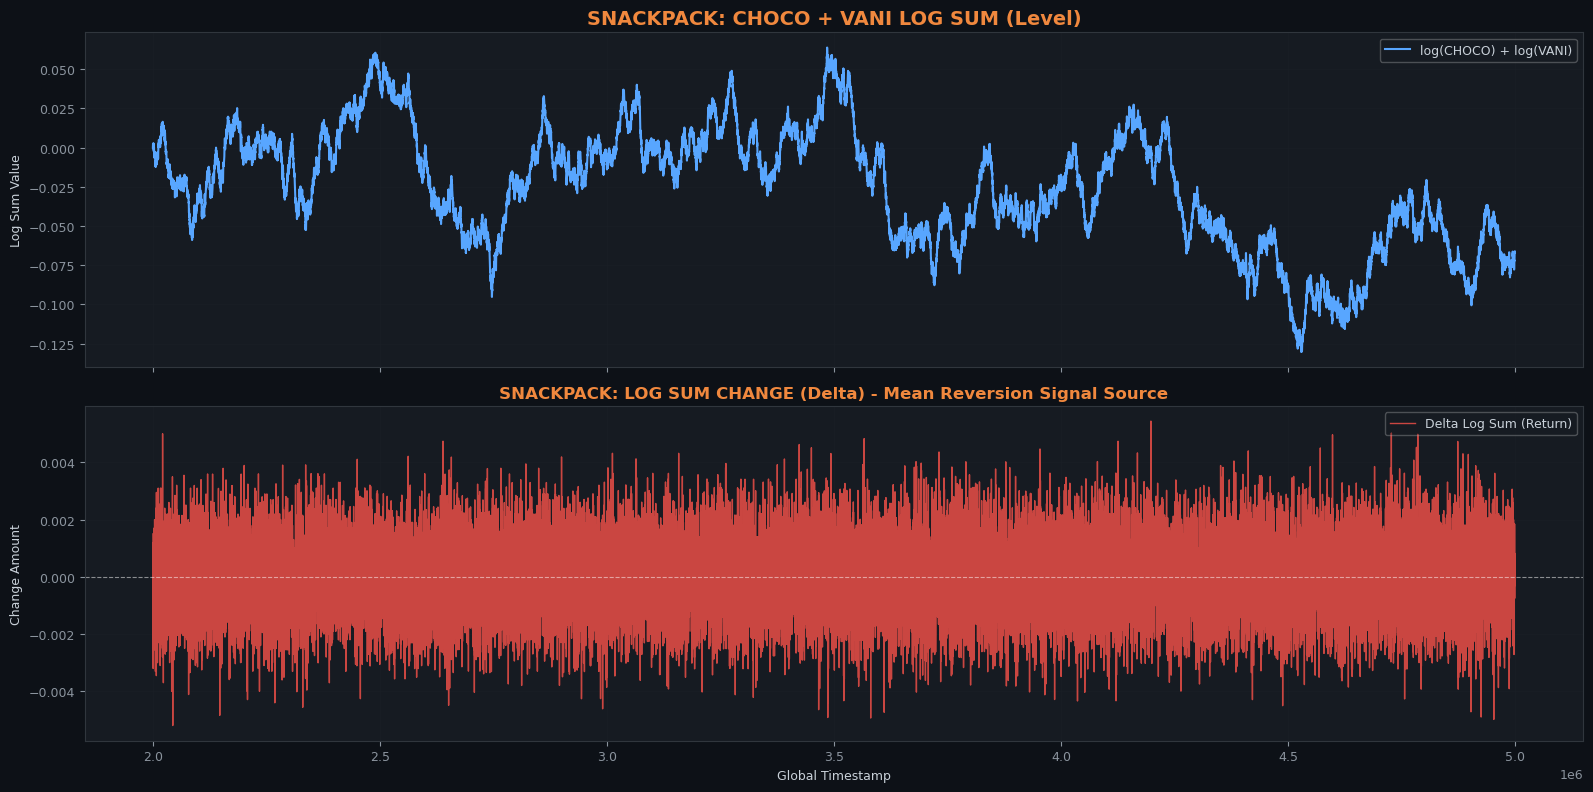

In [6]:
if 'prices' in locals():
    # 1. Extract data
    choco = prices[prices['product'] == 'SNACKPACK_CHOCOLATE'].sort_values('global_ts').set_index('global_ts')['mid_price']
    vani = prices[prices['product'] == 'SNACKPACK_VANILLA'].sort_values('global_ts').set_index('global_ts')['mid_price']
    
    # 2. Merge on common timestamp index
    cv_df = pd.DataFrame({'CHOCO': choco, 'VANI': vani}).dropna()
    
    # 3. Compute log-sum (weights w1=1, w2=1)
    cv_df['LOG_SUM'] = np.log(cv_df['CHOCO']) - np.log(cv_df['VANI'])
    cv_df['LOG_SUM_DIFF'] = cv_df['LOG_SUM'].diff()
    
    # 4. Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    
    # Top: Log Sum Level
    ax1.plot(cv_df.index, cv_df['LOG_SUM'], color='#58a6ff', linewidth=1.5, label='log(CHOCO) + log(VANI)')
    ax1.set_title('SNACKPACK: CHOCO + VANI LOG SUM (Level)', fontsize=14, fontweight='bold', color='#f0883e')
    ax1.set_ylabel('Log Sum Value')
    ax1.legend(loc='upper right', framealpha=0.3)
    ax1.grid(True, alpha=0.2)
    
    # Bottom: Log Sum Delta (return)
    ax2.plot(cv_df.index, cv_df['LOG_SUM_DIFF'], color='#f85149', linewidth=1, alpha=0.8, label='Delta Log Sum (Return)')
    ax2.axhline(0, color='white', linewidth=0.8, alpha=0.5, linestyle='--')
    ax2.set_title('SNACKPACK: LOG SUM CHANGE (Delta) - Mean Reversion Signal Source', fontsize=12, fontweight='bold', color='#f0883e')
    ax2.set_ylabel('Change Amount')
    ax2.set_xlabel('Global Timestamp')
    ax2.legend(loc='upper right', framealpha=0.3)
    ax2.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()

### SNACKPACK: Minimum Volatility PCA Basket

PCA-derived minimum-variance basket across all 5 SNACKPACK variants. Weights: CHOC ×1.0, VANI ×0.958, PISTA ×−0.111, STRAW ×0.138, RASP ×−0.016.

> **Finding:** The basket variance was reduced but the residual series showed no mean-reverting structure exploitable within the spread cost constraint. PCA basket construction without a stationary spread hypothesis is just variance reduction, not a trading signal.


## 12. SNACKPACK: Minimum Volatility PCA Basket

In [ ]:
if 'prices' in locals():
    # 1. Pivot all SNACKPACK assets
    sp_prods = CATEGORIES['SNACKPACK']
    sp_pivot = prices[prices['product'].isin(sp_prods)].pivot_table(
        index='global_ts', columns='product', values='mid_price'
    ).dropna()
    
    # 2. Apply PCA minimum-volatility weights (from analysis result)
    # Weights: CHOC: 1.0, VANI: 0.9579, PISTA: -0.1106, STRAW: 0.1379, RASP: -0.0158
    weights = {
        'SNACKPACK_CHOCOLATE': 1.0000,
        'SNACKPACK_VANILLA': 0.9579,
        'SNACKPACK_PISTACHIO': -0.1106,
        'SNACKPACK_STRAWBERRY': 0.1379,
        'SNACKPACK_RASPBERRY': -0.0158
    }
    
    sp_pivot['MinVol_Basket'] = 0
    for prod, w in weights.items():
        if prod in sp_pivot.columns:
            sp_pivot['MinVol_Basket'] += sp_pivot[prod] * w
            
    # 3. Compute summary statistics
    mean_val = sp_pivot['MinVol_Basket'].mean()
    std_val = sp_pivot['MinVol_Basket'].std()
    
    # 4. Visualization
    plt.figure(figsize=(16, 6))
    plt.plot(sp_pivot.index, sp_pivot['MinVol_Basket'], color='#58a6ff', linewidth=1, label='Min-Vol PCA Basket')
    
    # Mean and standard deviation band
    plt.axhline(mean_val, color='#f0883e', linestyle='-', linewidth=1.5, label=f'Mean ({mean_val:.2f})')
    plt.axhline(mean_val + 2*std_val, color='#f85149', linestyle='--', linewidth=1, alpha=0.6, label='±2 Sigma')
    plt.axhline(mean_val - 2*std_val, color='#f85149', linestyle='--', linewidth=1, alpha=0.6)
    
    plt.fill_between(sp_pivot.index, mean_val - 2*std_val, mean_val + 2*std_val, color='#f85149', alpha=0.05)
    
    plt.title('SNACKPACK: MINIMUM VOLATILITY PCA BASKET', fontsize=14, fontweight='bold', color='#58a6ff')
    plt.xlabel('Global Timestamp')
    plt.ylabel('Basket Price Sum')
    plt.legend(loc='upper right', framealpha=0.3)
    plt.grid(True, alpha=0.2)
    
    print(f"Basket Volatility (Std Dev): {std_val:.4f}")
    print(f"Current Deviation from Mean: {sp_pivot['MinVol_Basket'].iloc[-1] - mean_val:.4f}")
    
    plt.tight_layout()
    plt.show()

---

## Phase 4: OBI-Based Lead-Lag — Sector-by-Sector

*This is where the most time was spent. The organizer hint about lead-lag pushed the research heavily toward OBI as the leading indicator.*

The approach: for each sector, treat OBI spikes from one product as a signal, then measure how the price of other products in the same sector moves over the next N ticks.

Tested sectors: **SNACKPACK** (cells below), **TRANSLATOR**, **SLEEP_POD**.

> ⚠️ **Critical flaw:** All tests below were run on **Day 2 only**. No OOS validation across Day 3 or Day 4 was completed before time ran out. This is the core failure — signals that appeared directional on Day 2 were not verified to be stable.


c:\Users\dhko23\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Loading data...
Calculating micro prices...
Pivoting data and calculating sector sums...
Plotting data...

✅ Plot successfully saved to d:\imc\ROUND5\sector_micro_price_sum.png


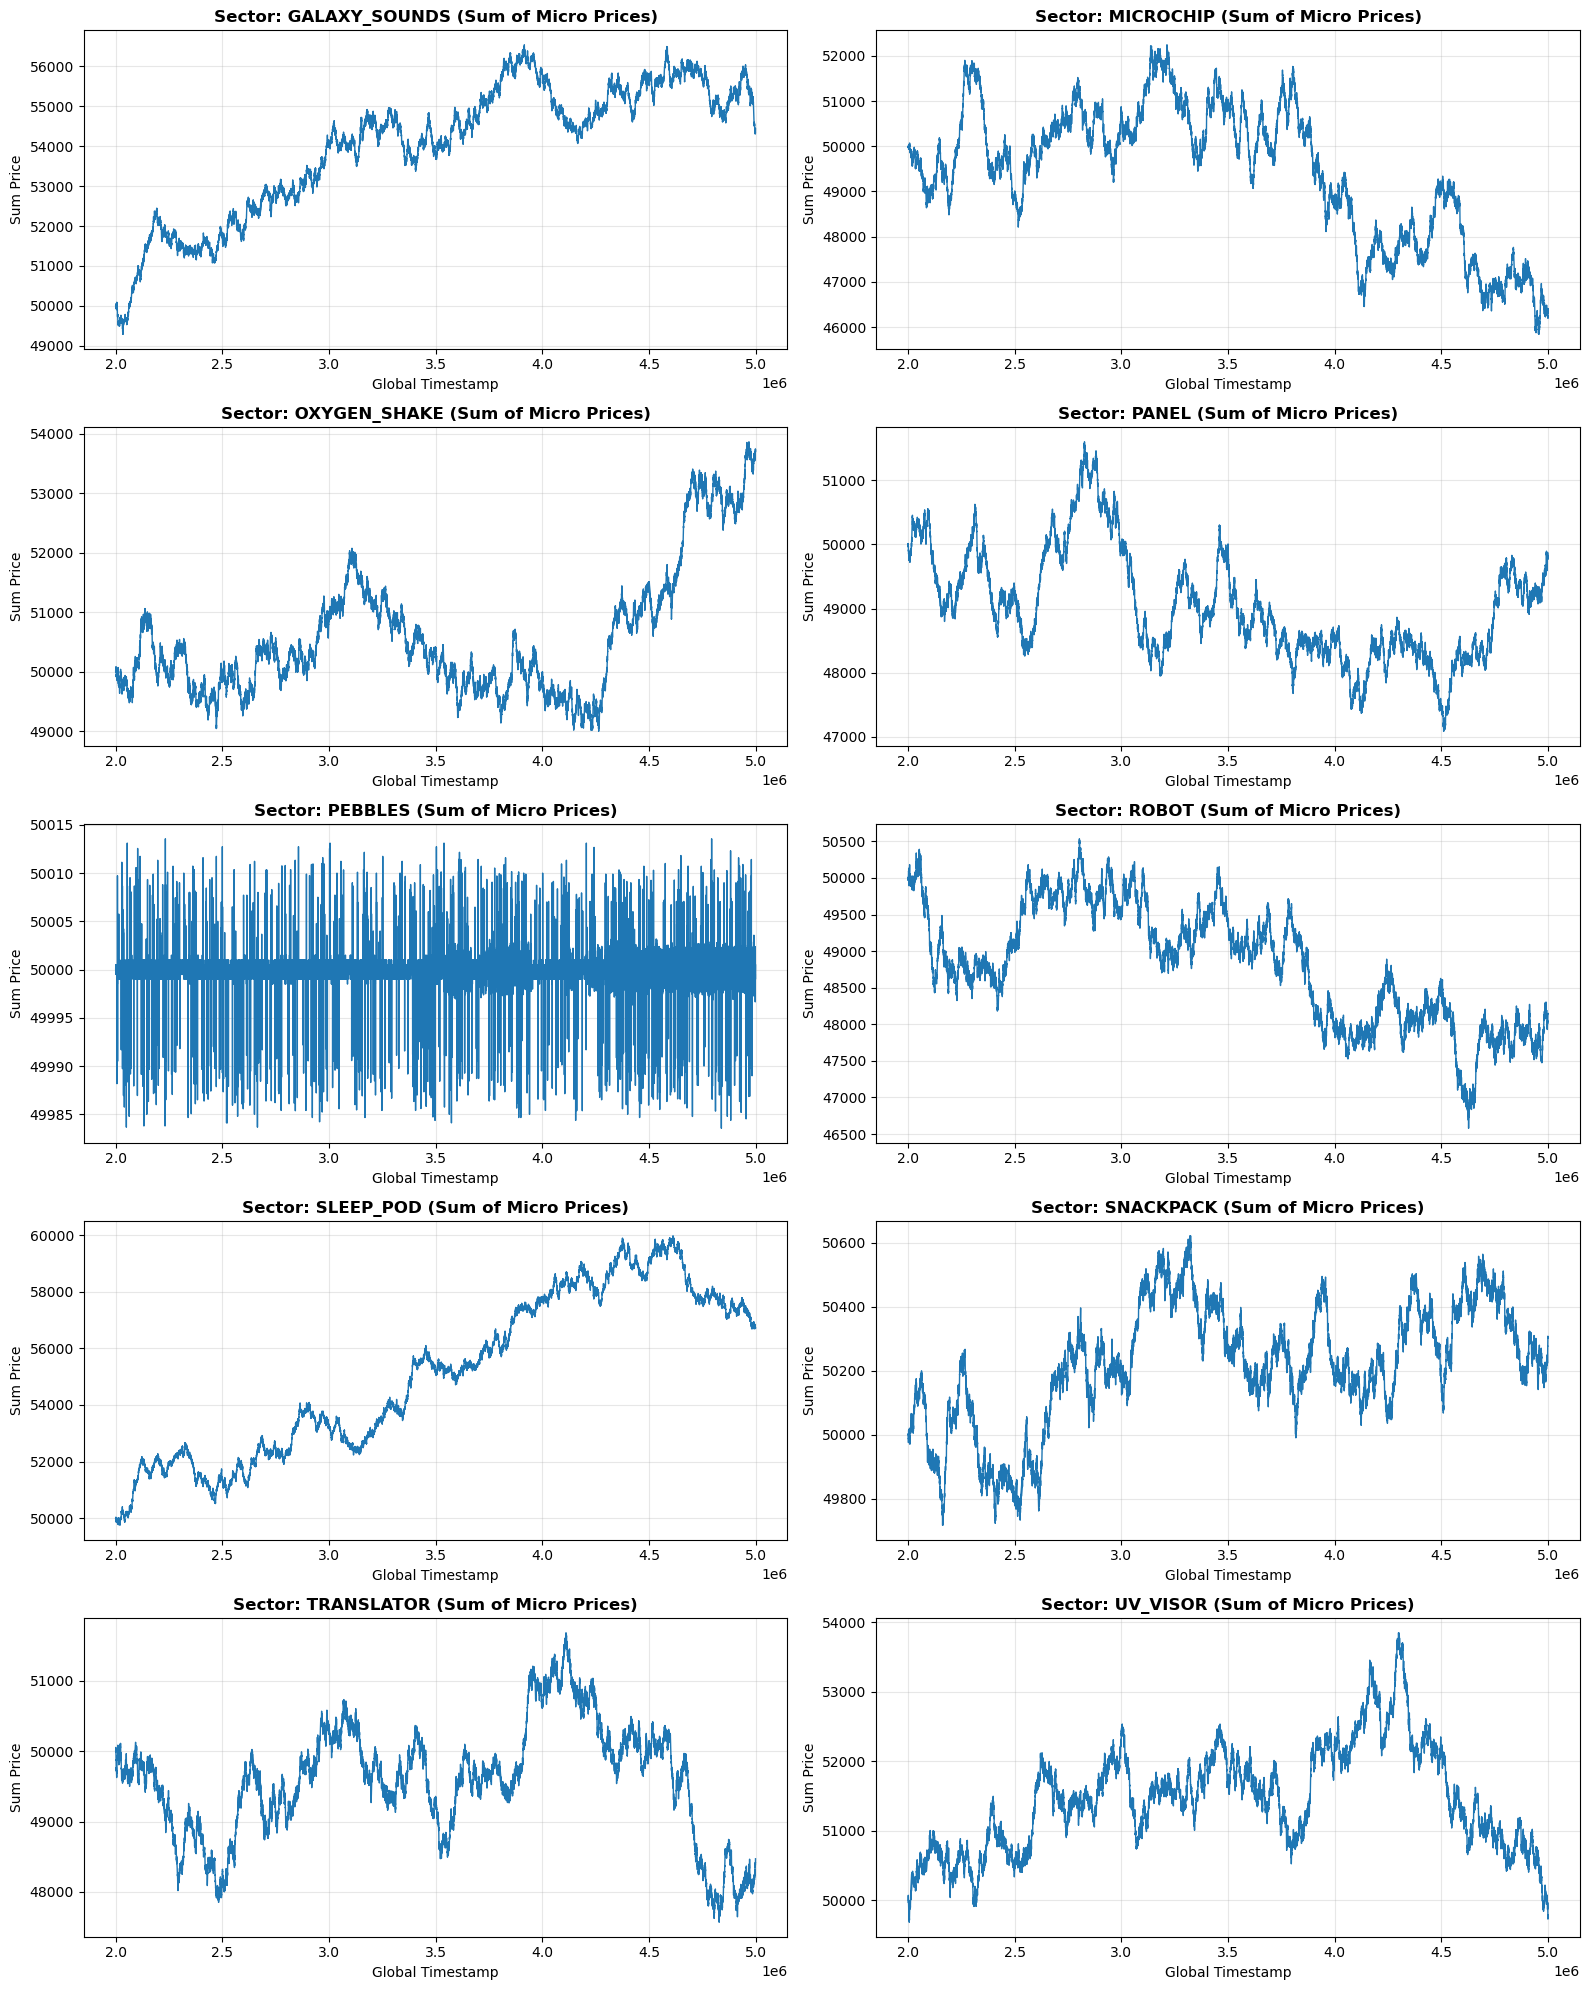

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

DATA_DIR = Path(r"d:\imc\ROUND5")

def main():
    print("Loading data...")
    frames = []
    # Load data for days 2, 3, and 4 (change filename to test specific days)
    for f in sorted(DATA_DIR.glob("prices_round_5_day_*.csv")):
        frames.append(pd.read_csv(f, sep=';'))
    prices = pd.concat(frames, ignore_index=True)
    prices['global_ts'] = prices['day'] * 1_000_000 + prices['timestamp']

    # Assign category labels
    CATEGORIES = {
        'GALAXY_SOUNDS': [], 'MICROCHIP': [], 'OXYGEN_SHAKE': [],
        'PANEL': [], 'PEBBLES': [], 'ROBOT': [],
        'SLEEP_POD': [], 'SNACKPACK': [], 'TRANSLATOR': [], 'UV_VISOR': []
    }
    
    for p in sorted(prices['product'].unique()):
        for cat in CATEGORIES:
            if p.startswith(cat):
                CATEGORIES[cat].append(p)
                break

    # Compute micro-price
    print("Calculating micro prices...")
    bid_p = prices['bid_price_1'].fillna(prices['mid_price'])
    ask_p = prices['ask_price_1'].fillna(prices['mid_price'])
    bid_v = prices['bid_volume_1'].fillna(0)
    ask_v = prices['ask_volume_1'].fillna(0)
    
    vol_sum = bid_v + ask_v
    vol_sum_safe = vol_sum.replace(0, 1)

    prices['micro_price'] = (bid_p * ask_v + ask_p * bid_v) / vol_sum_safe
    
    # Fall back to mid_price when all volumes are zero
    mask_zero_vol = (bid_v == 0) & (ask_v == 0)
    prices.loc[mask_zero_vol, 'micro_price'] = prices.loc[mask_zero_vol, 'mid_price']

    # Pivot: build micro-price table indexed by timestamp per product
    print("Pivoting data and calculating sector sums...")
    pivot = prices.pivot_table(index='global_ts', columns='product', values='micro_price').ffill()

    # Compute sector totals
    sector_sums = pd.DataFrame(index=pivot.index)
    for cat, prods in CATEGORIES.items():
        if not prods: continue
        sector_sums[cat] = pivot[prods].sum(axis=1)

    # Visualization (Subplot)
    print("Plotting data...")
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))
    axes = axes.flatten()

    for i, cat in enumerate(CATEGORIES.keys()):
        if cat in sector_sums.columns:
            axes[i].plot(sector_sums.index, sector_sums[cat], lw=1)
            axes[i].set_title(f"Sector: {cat} (Sum of Micro Prices)", fontsize=12, fontweight='bold')
            axes[i].set_xlabel("Global Timestamp")
            axes[i].set_ylabel("Sum Price")
            axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    
    save_path = DATA_DIR / "sector_micro_price_sum.png"
    plt.savefig(save_path, dpi=150)
    print(f"\n✅ Plot successfully saved to {save_path}")

if __name__ == "__main__":
    main()


#### SNACKPACK: Intra-group OBI Lead-Lag Test

Testing whether OBI spikes in VANILLA, RASPBERRY, or STRAWBERRY predict short-term price moves in other SNACKPACK variants.

> **Finding:** Some directional response was visible at 1–5 tick lags, but signal magnitude was smaller than the bid-ask spread. Entry at the ask (buy signal) or bid (sell signal) immediately put the position at a loss that the subsequent move couldn't recover. Net edge: negative after spread costs.


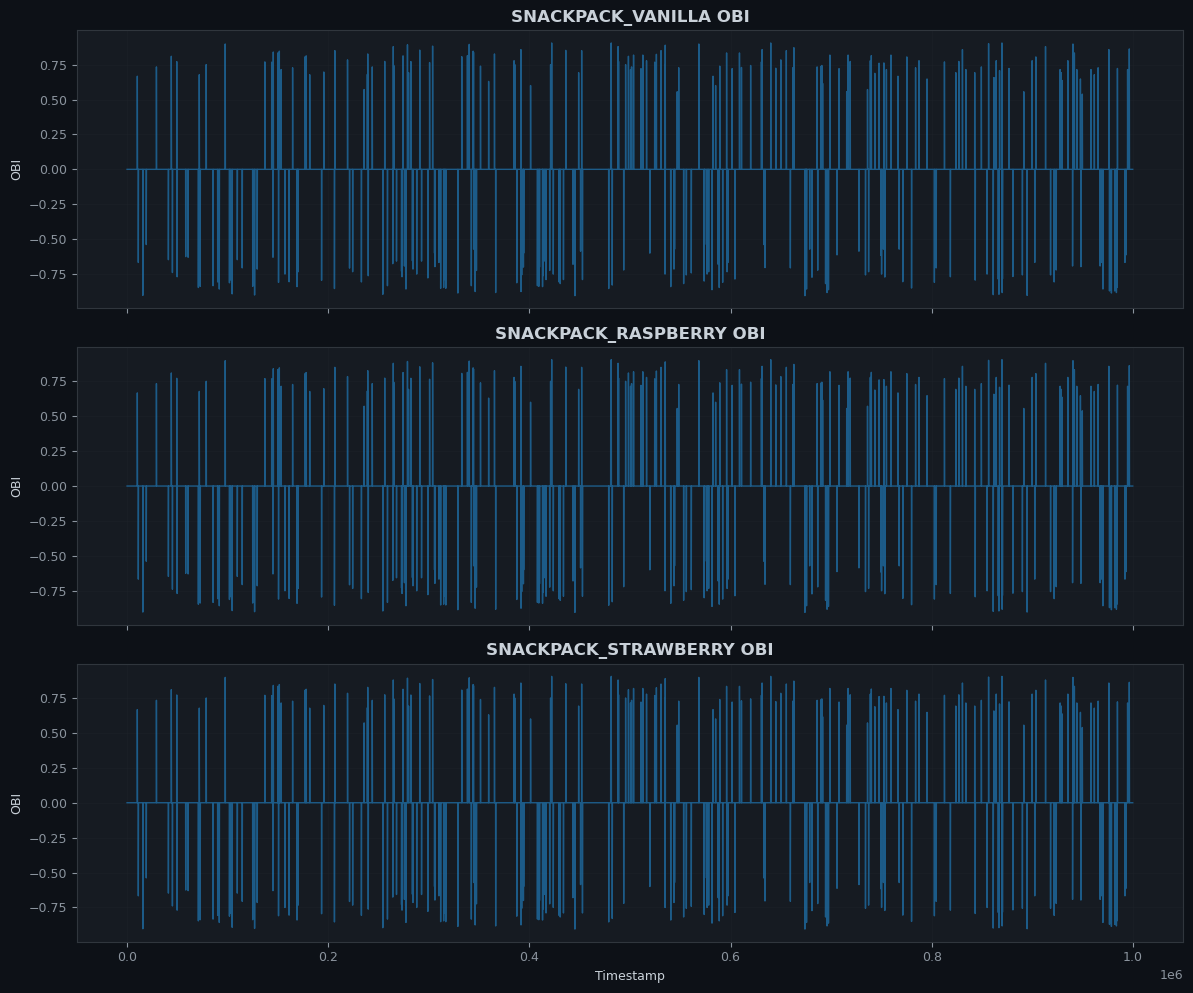

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Set data directory path
DATA_DIR = Path(r"d:\imc\ROUND5")

# Load data (change filename as needed)
prices = pd.read_csv(DATA_DIR / "prices_round_5_day_2.csv", sep=';')

# Set target products
targets = ['SNACKPACK_VANILLA', 'SNACKPACK_RASPBERRY', 'SNACKPACK_STRAWBERRY']
df_target = prices[prices['product'].isin(targets)].copy()

# Compute OBI
df_target['bid_vol'] = df_target['bid_volume_1'].fillna(0)
df_target['ask_vol'] = df_target['ask_volume_1'].fillna(0)
vol_sum = df_target['bid_vol'] + df_target['ask_vol']

# Prevent division by zero
vol_sum = vol_sum.replace(0, 1)
df_target['obi'] = (df_target['bid_vol'] - df_target['ask_vol']) / vol_sum

# Create subplot grid
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True)

for i, product in enumerate(targets):
    # Extract and sort data for this product
    prod_data = df_target[df_target['product'] == product].sort_values('timestamp')
    
    # Plot
    axes[i].plot(prod_data['timestamp'], prod_data['obi'], lw=1, color='tab:blue', alpha=0.7)
    axes[i].set_title(f"{product} OBI", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("OBI")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()


#### SNACKPACK → PISTACHIO Lead-Lag Test

Specifically testing whether VANILLA/RASPBERRY/STRAWBERRY OBI leads PISTACHIO price moves.

> **Finding:** Weak correlation at short lags, no persistence beyond 5 ticks. Signal noise exceeded signal. Not tradeable.


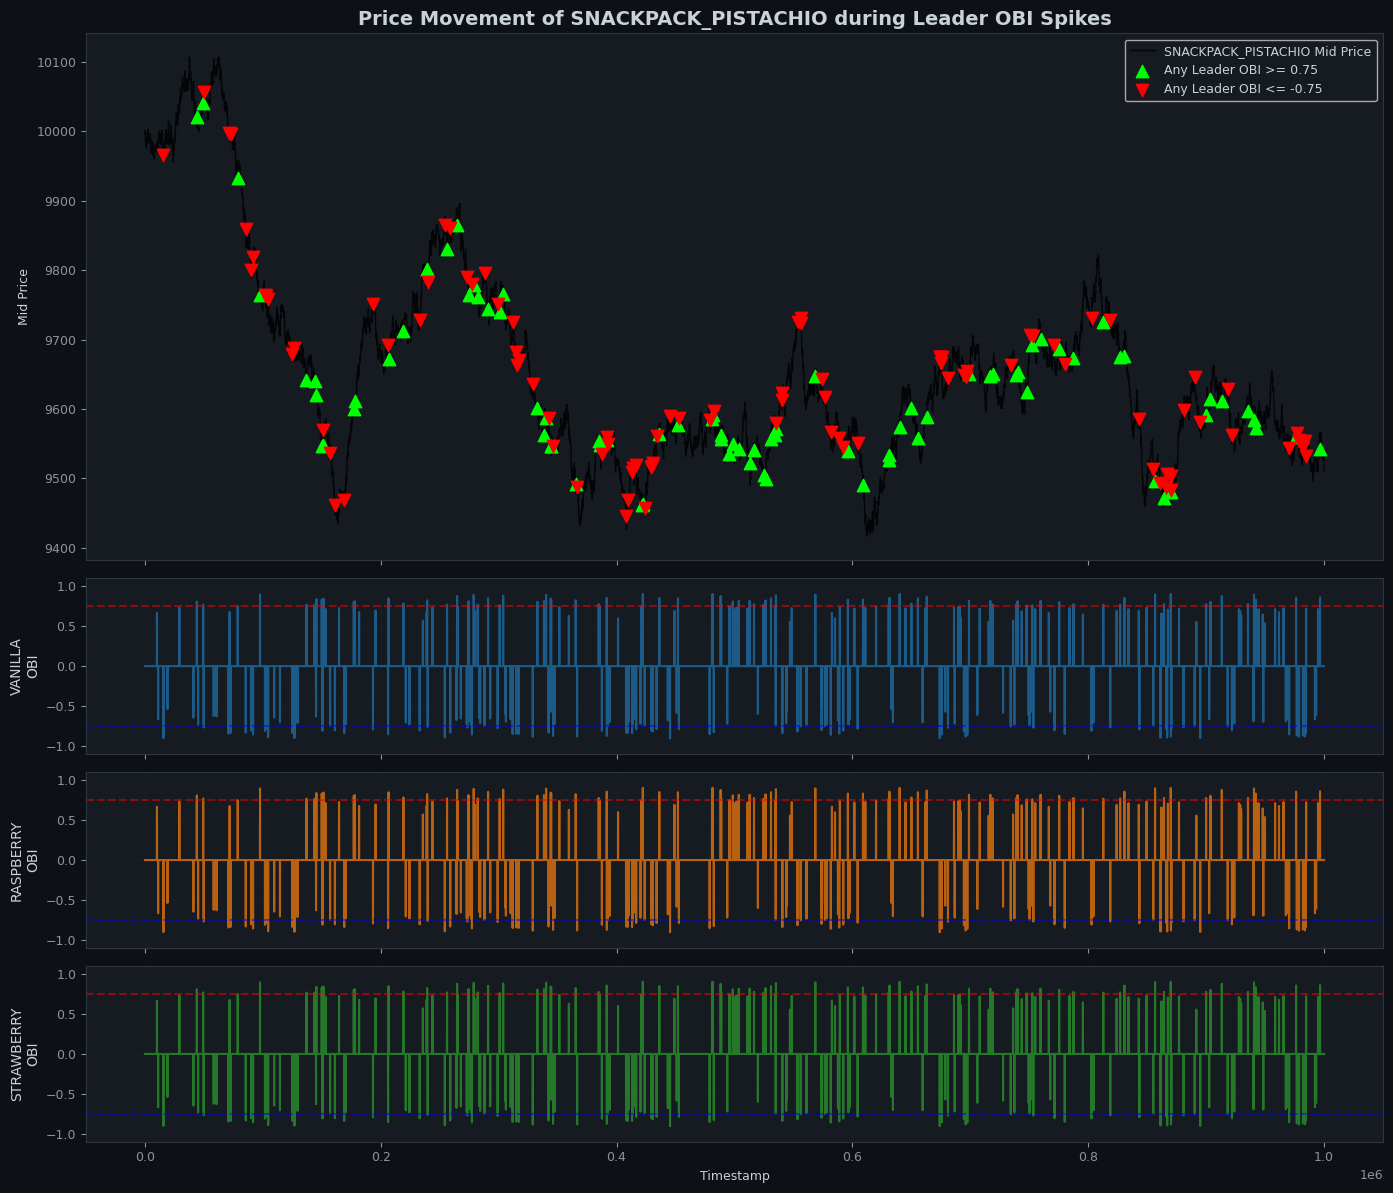

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Set data directory path
DATA_DIR = Path(r"d:\imc\ROUND5")

# Load data (Day 2 data; change file as needed for OOS testing)
prices = pd.read_csv(DATA_DIR / "prices_round_5_day_2.csv", sep=';')

# Set products of interest
leaders = ['SNACKPACK_VANILLA', 'SNACKPACK_RASPBERRY', 'SNACKPACK_STRAWBERRY']
target = 'SNACKPACK_PISTACHIO'

# Extract data and compute OBI
df_filtered = prices[prices['product'].isin(leaders + [target])].copy()
df_filtered['bid_vol'] = df_filtered['bid_volume_1'].fillna(0)
df_filtered['ask_vol'] = df_filtered['ask_volume_1'].fillna(0)
df_filtered['vol_sum'] = (df_filtered['bid_vol'] + df_filtered['ask_vol']).replace(0, 1)
df_filtered['obi'] = (df_filtered['bid_vol'] - df_filtered['ask_vol']) / df_filtered['vol_sum']

# Pivot by timestamp
pivot_obi = df_filtered[df_filtered['product'].isin(leaders)].pivot_table(index='timestamp', columns='product', values='obi').fillna(0)
pivot_price = df_filtered[df_filtered['product'] == target].set_index('timestamp')['mid_price']

# OBI spike condition: trigger if any one of the 3 leaders crosses threshold
threshold = 0.75
buy_signals = pivot_obi[(pivot_obi >= threshold).any(axis=1)].index
sell_signals = pivot_obi[(pivot_obi <= -threshold).any(axis=1)].index

# Plot layout: top = PISTACHIO price; bottom 3 = each leader's OBI
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1, 1]})

# 1. Plot PISTACHIO price
ax_price = axes[0]
ax_price.plot(pivot_price.index, pivot_price.values, label=f'{target} Mid Price', color='black', alpha=0.8, lw=1)

# Mark OBI spike events on chart
buy_prices = pivot_price.loc[pivot_price.index.intersection(buy_signals)]
sell_prices = pivot_price.loc[pivot_price.index.intersection(sell_signals)]
ax_price.scatter(buy_prices.index, buy_prices.values, color='lime', marker='^', s=80, label=f'Any Leader OBI >= {threshold}', zorder=5)
ax_price.scatter(sell_prices.index, sell_prices.values, color='red', marker='v', s=80, label=f'Any Leader OBI <= -{threshold}', zorder=5)

ax_price.set_title(f"Price Movement of {target} during Leader OBI Spikes", fontsize=14, fontweight='bold')
ax_price.set_ylabel("Mid Price")
ax_price.legend()
ax_price.grid(True, alpha=0.3)

# 2. Plot each leader's OBI
colors = ['tab:blue', 'tab:orange', 'tab:green']
for i, leader in enumerate(leaders):
    ax = axes[i + 1]
    ax.plot(pivot_obi.index, pivot_obi[leader], color=colors[i], alpha=0.7)
    
    # Reference lines at ±0.75
    ax.axhline(threshold, color='red', linestyle='--', alpha=0.5)
    ax.axhline(-threshold, color='blue', linestyle='--', alpha=0.5)
    
    # Shorten y-axis label (e.g. VANILLA OBI)
    ax.set_ylabel(f"{leader.split('_')[1]}\nOBI", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.1, 1.1)

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()


#### TRANSLATOR: Intra-group OBI Analysis

Same OBI lead-lag framework applied to the TRANSLATOR sector (SPACE_GRAY, ECLIPSE_CHARCOAL, VOID_BLUE variants).

> **Finding:** OBI distributions were more concentrated around zero compared to SNACKPACK. Lower OBI variance meant fewer signal triggers and weaker predictive content. No useful signal.


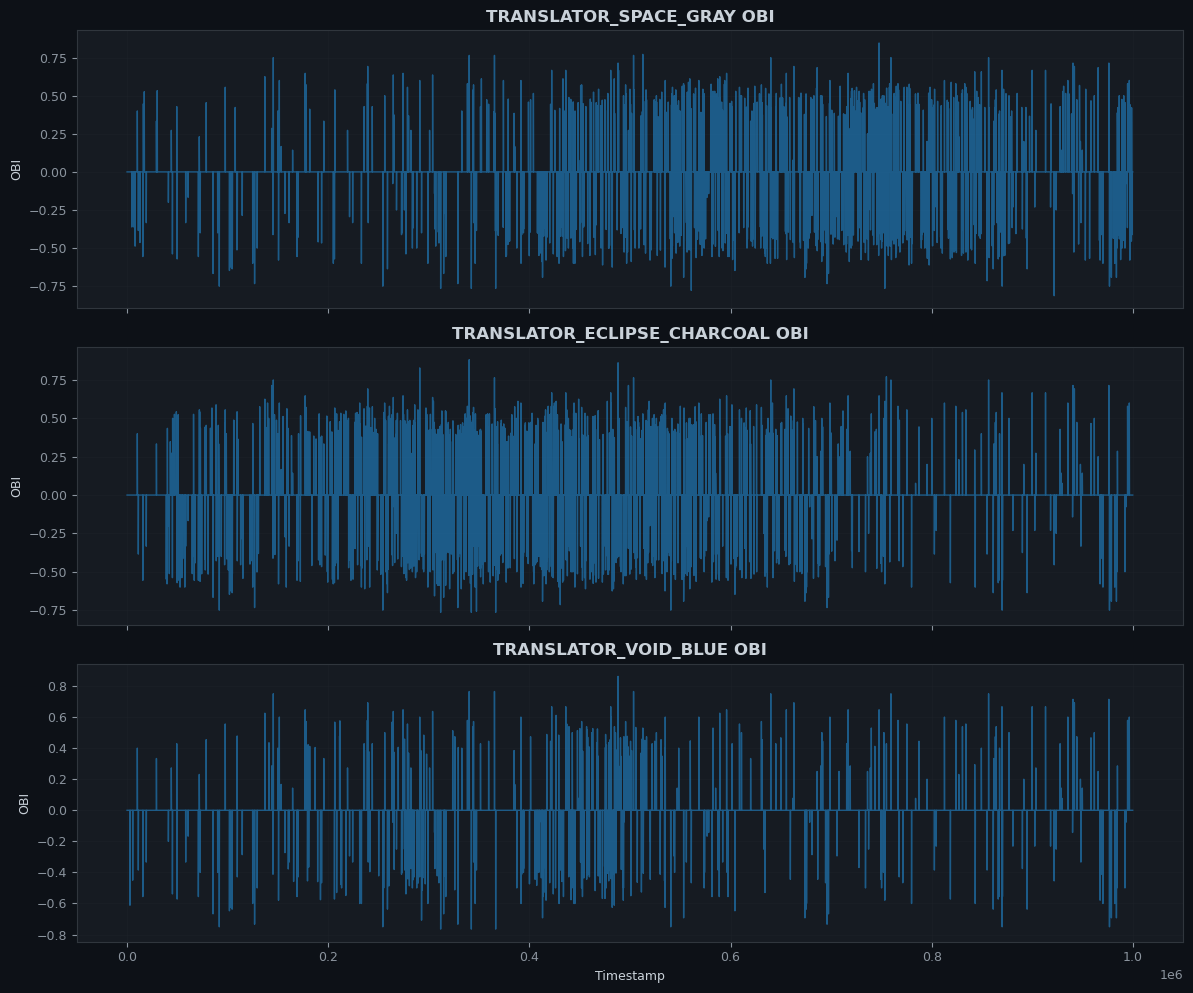

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Set data directory path
DATA_DIR = Path(r"d:\imc\ROUND5")

# Load data (Day 2 data; change file as needed for OOS testing)
prices = pd.read_csv(DATA_DIR / "prices_round_5_day_2.csv", sep=';')

# Set target products (TRANSLATOR sector)
targets = ['TRANSLATOR_SPACE_GRAY', 'TRANSLATOR_ECLIPSE_CHARCOAL', 'TRANSLATOR_VOID_BLUE']
df_target = prices[prices['product'].isin(targets)].copy()

# Compute OBI
df_target['bid_vol'] = df_target['bid_volume_1'].fillna(0)
df_target['ask_vol'] = df_target['ask_volume_1'].fillna(0)
vol_sum = df_target['bid_vol'] + df_target['ask_vol']

# Prevent division by zero
vol_sum = vol_sum.replace(0, 1)
df_target['obi'] = (df_target['bid_vol'] - df_target['ask_vol']) / vol_sum

# Create subplot grid
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True)

for i, product in enumerate(targets):
    # Extract and sort data for this product
    prod_data = df_target[df_target['product'] == product].sort_values('timestamp')
    
    # Plot
    axes[i].plot(prod_data['timestamp'], prod_data['obi'], lw=1, color='tab:blue', alpha=0.7)
    axes[i].set_title(f"{product} OBI", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("OBI")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()


#### TRANSLATOR: Cross-product Lead-Lag

Testing SPACE_GRAY / ECLIPSE_CHARCOAL / VOID_BLUE OBI → GRAPHITE_MIST price response.

> **Finding:** No consistent directional response. Forward price curves (mid, ask, bid) were approximately flat after signal triggers, indistinguishable from noise.


=== TRANSLATOR_GRAPHITE_MIST 가격 변화량 (t -> t+1) 통계 ===

[TRANSLATOR_SPACE_GRAY]
 - OBI >= 0.5  평균 가격 변화: +0.3179 (표본 수: 173)
 - OBI <= -0.5 평균 가격 변화: -0.3533 (표본 수: 184)

[TRANSLATOR_ECLIPSE_CHARCOAL]
 - OBI >= 0.5  평균 가격 변화: +0.2315 (표본 수: 203)
 - OBI <= -0.5 평균 가격 변화: -0.3333 (표본 수: 222)

[TRANSLATOR_VOID_BLUE]
 - OBI >= 0.5  평균 가격 변화: +1.0920 (표본 수: 87)
 - OBI <= -0.5 평균 가격 변화: -0.1893 (표본 수: 103)


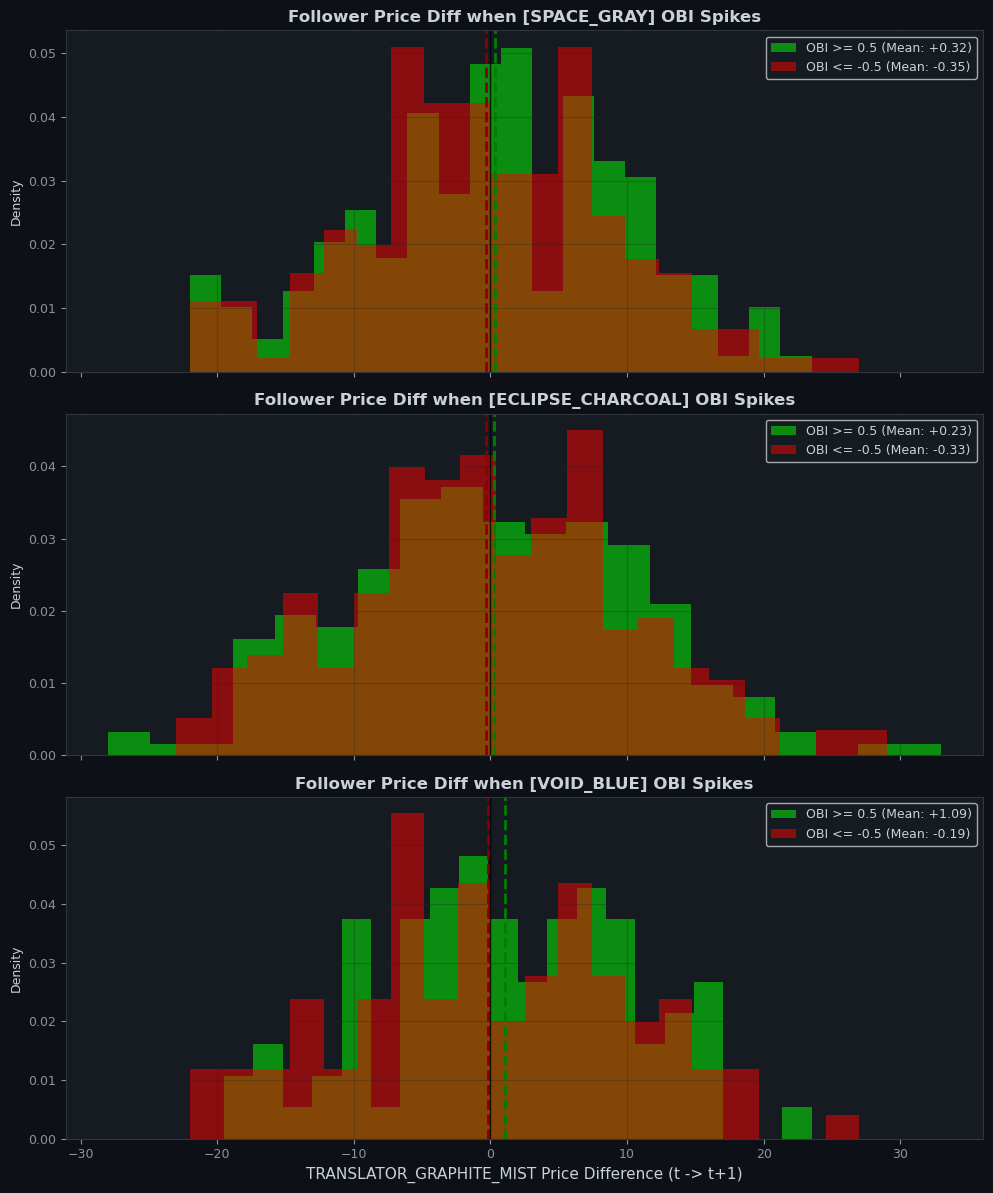

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Set data directory path
DATA_DIR = Path(r"d:\imc\ROUND5")

# Load data (Day 2)
prices = pd.read_csv(DATA_DIR / "prices_round_5_day_2.csv", sep=';')

# Set products of interest
leaders = ['TRANSLATOR_SPACE_GRAY', 'TRANSLATOR_ECLIPSE_CHARCOAL', 'TRANSLATOR_VOID_BLUE']
follower = 'TRANSLATOR_GRAPHITE_MIST'

# Extract and clean data
df_filtered = prices[prices['product'].isin(leaders + [follower])].copy()

# Compute OBI
df_filtered['bid_vol'] = df_filtered['bid_volume_1'].fillna(0)
df_filtered['ask_vol'] = df_filtered['ask_volume_1'].fillna(0)
df_filtered['vol_sum'] = (df_filtered['bid_vol'] + df_filtered['ask_vol']).replace(0, 1)
df_filtered['obi'] = (df_filtered['bid_vol'] - df_filtered['ask_vol']) / df_filtered['vol_sum']

# Build pivot table
pivot_obi = df_filtered[df_filtered['product'].isin(leaders)].pivot_table(index='timestamp', columns='product', values='obi').fillna(0)
pivot_price = df_filtered[df_filtered['product'] == follower].set_index('timestamp')['mid_price']

# Compute follower's next-tick price change (Price(t+1) − Price(t))
# 1-tick profit from entering at t based on OBI signal at t
follower_diff = pivot_price.diff().shift(-1)

# OBI threshold
threshold = 0.5

# Visualization: subplot per leader (3 total)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=True)

print(f"=== {follower} Price change statistics (t → t+1) ===")

for i, leader in enumerate(leaders):
    # Extract timestamps satisfying the condition
    buy_times = pivot_obi[pivot_obi[leader] >= threshold].index
    sell_times = pivot_obi[pivot_obi[leader] <= -threshold].index
    
    # Follower price change at matching timestamps (drop last-tick NaN)
    buy_diffs = follower_diff.loc[follower_diff.index.intersection(buy_times)].dropna()
    sell_diffs = follower_diff.loc[follower_diff.index.intersection(sell_times)].dropna()
    
    # Compute mean
    buy_mean = buy_diffs.mean() if len(buy_diffs) > 0 else 0
    sell_mean = sell_diffs.mean() if len(sell_diffs) > 0 else 0
    
    print(f"\n[{leader}]")
    print(f" - OBI >= {threshold}  mean price change: {buy_mean:+.4f} (sample count: {len(buy_diffs)})")
    print(f" - OBI <= -{threshold} mean price change: {sell_mean:+.4f} (sample count: {len(sell_diffs)})")
    
    # Draw histogram
    ax = axes[i]
    
    # Histogram (density=True to show relative frequency distribution)
    ax.hist(buy_diffs, bins=20, alpha=0.5, color='lime', label=f'OBI >= {threshold} (Mean: {buy_mean:+.2f})', density=True)
    ax.hist(sell_diffs, bins=20, alpha=0.5, color='red', label=f'OBI <= -{threshold} (Mean: {sell_mean:+.2f})', density=True)
    
    # Show mean line (dashed)
    ax.axvline(buy_mean, color='green', linestyle='dashed', linewidth=2)
    ax.axvline(sell_mean, color='darkred', linestyle='dashed', linewidth=2)
    
    # Zero-profit reference line (solid)
    ax.axvline(0, color='black', linewidth=1, alpha=0.8) 
    
    ax.set_title(f"Follower Price Diff when [{leader.split('_', 1)[1]}] OBI Spikes", fontsize=12, fontweight='bold')
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel(f"{follower} Price Difference (t -> t+1)", fontsize=11)
plt.tight_layout()
plt.show()


=== TRANSLATOR_GRAPHITE_MIST 진입 후 N틱 누적 가격 변화(수익) 평균 ===

[TRANSLATOR_SPACE_GRAY]
 OBI >= 0.5 (매수) 1~10틱 평균 수익: [0.32, -1.22, -0.99, -1.28, -1.88, -0.34, -0.95, -0.29, -0.21, 0.76]
 OBI <= -0.5 (매도) 1~10틱 평균 수익: [-0.35, -1.12, -1.54, -1.83, -2.46, -3.32, -3.32, -3.88, -4.16, -5.3]

[TRANSLATOR_ECLIPSE_CHARCOAL]
 OBI >= 0.5 (매수) 1~10틱 평균 수익: [0.23, -0.3, -0.01, -0.44, 0.26, 0.83, 1.46, 2.43, 2.96, 3.37]
 OBI <= -0.5 (매도) 1~10틱 평균 수익: [-0.33, -0.9, -0.75, -1.48, -2.25, -3.02, -3.21, -4.08, -4.89, -5.7]

[TRANSLATOR_VOID_BLUE]
 OBI >= 0.5 (매수) 1~10틱 평균 수익: [1.09, 1.45, 1.9, 2.13, 2.14, 2.65, 3.38, 5.11, 5.5, 5.35]
 OBI <= -0.5 (매도) 1~10틱 평균 수익: [-0.19, -2.2, -3.29, -3.99, -4.81, -5.49, -5.18, -6.86, -7.85, -8.39]


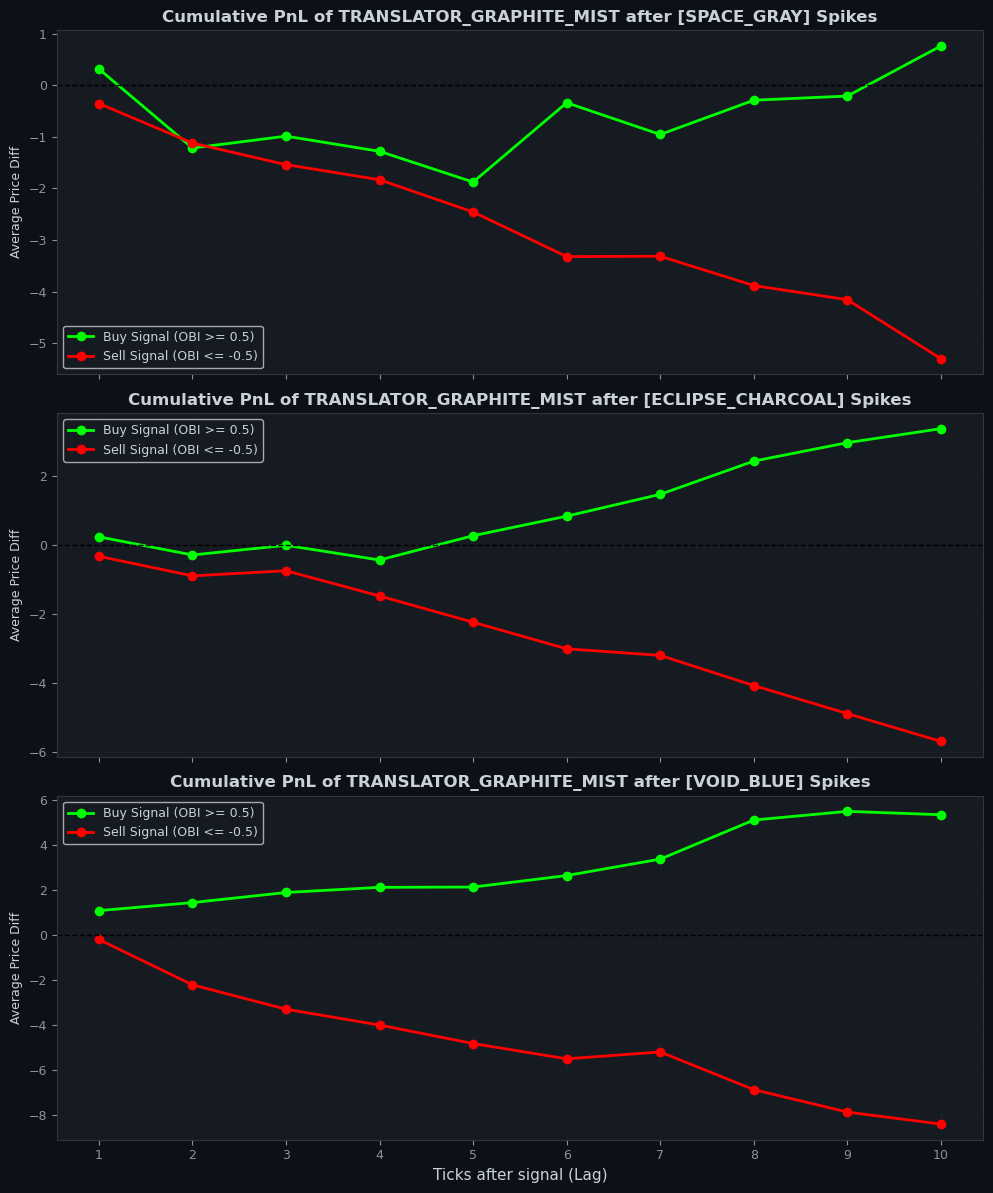

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Set data directory path
DATA_DIR = Path(r"d:\imc\ROUND5")

# Load data (Day 2)
prices = pd.read_csv(DATA_DIR / "prices_round_5_day_2.csv", sep=';')

# Set products of interest
leaders = ['TRANSLATOR_SPACE_GRAY', 'TRANSLATOR_ECLIPSE_CHARCOAL', 'TRANSLATOR_VOID_BLUE']
follower = 'TRANSLATOR_GRAPHITE_MIST'

# Extract and clean data
df_filtered = prices[prices['product'].isin(leaders + [follower])].copy()

# Compute OBI
df_filtered['bid_vol'] = df_filtered['bid_volume_1'].fillna(0)
df_filtered['ask_vol'] = df_filtered['ask_volume_1'].fillna(0)
df_filtered['vol_sum'] = (df_filtered['bid_vol'] + df_filtered['ask_vol']).replace(0, 1)
df_filtered['obi'] = (df_filtered['bid_vol'] - df_filtered['ask_vol']) / df_filtered['vol_sum']

pivot_obi = df_filtered[df_filtered['product'].isin(leaders)].pivot_table(index='timestamp', columns='product', values='obi').fillna(0)
pivot_price = df_filtered[df_filtered['product'] == follower].set_index('timestamp')['mid_price']

threshold = 0.5
MAX_LAG = 10

# Visualization setup
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=True)

print(f"=== {follower} Mean cumulative price change after N ticks from entry ===")

for i, leader in enumerate(leaders):
    # Signal trigger timestamps
    buy_times = pivot_obi[pivot_obi[leader] >= threshold].index
    sell_times = pivot_obi[pivot_obi[leader] <= -threshold].index
    
    buy_means = []
    sell_means = []
    
    for lag in range(1, MAX_LAG + 1):
        # Price change from entry at t to exit at t+lag (Price(t+lag) − Price(t))
        future_diff = pivot_price.shift(-lag) - pivot_price
        
        buy_diffs = future_diff.loc[future_diff.index.intersection(buy_times)].dropna()
        sell_diffs = future_diff.loc[future_diff.index.intersection(sell_times)].dropna()
        
        buy_means.append(buy_diffs.mean() if len(buy_diffs) > 0 else 0)
        sell_means.append(sell_diffs.mean() if len(sell_diffs) > 0 else 0)
        
    print(f"\n[{leader}]")
    print(f" OBI >= {threshold} (buy) mean 1–10 tick profit: {[round(x, 2) for x in buy_means]}")
    print(f" OBI <= -{threshold} (sell) mean 1–10 tick profit: {[round(x, 2) for x in sell_means]}")
    
    # Line chart visualization
    ax = axes[i]
    x_lags = np.arange(1, MAX_LAG + 1)
    
    # Plot buy/sell P&L curves
    ax.plot(x_lags, buy_means, marker='o', color='lime', linewidth=2, label=f'Buy Signal (OBI >= {threshold})')
    ax.plot(x_lags, sell_means, marker='o', color='red', linewidth=2, label=f'Sell Signal (OBI <= -{threshold})')
    
    # Zero-profit reference line
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    
    ax.set_title(f"Cumulative PnL of {follower} after [{leader.split('_', 1)[1]}] Spikes", fontsize=12, fontweight='bold')
    ax.set_ylabel("Average Price Diff")
    ax.set_xticks(x_lags)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Ticks after signal (Lag)", fontsize=11)
plt.tight_layout()
plt.show()


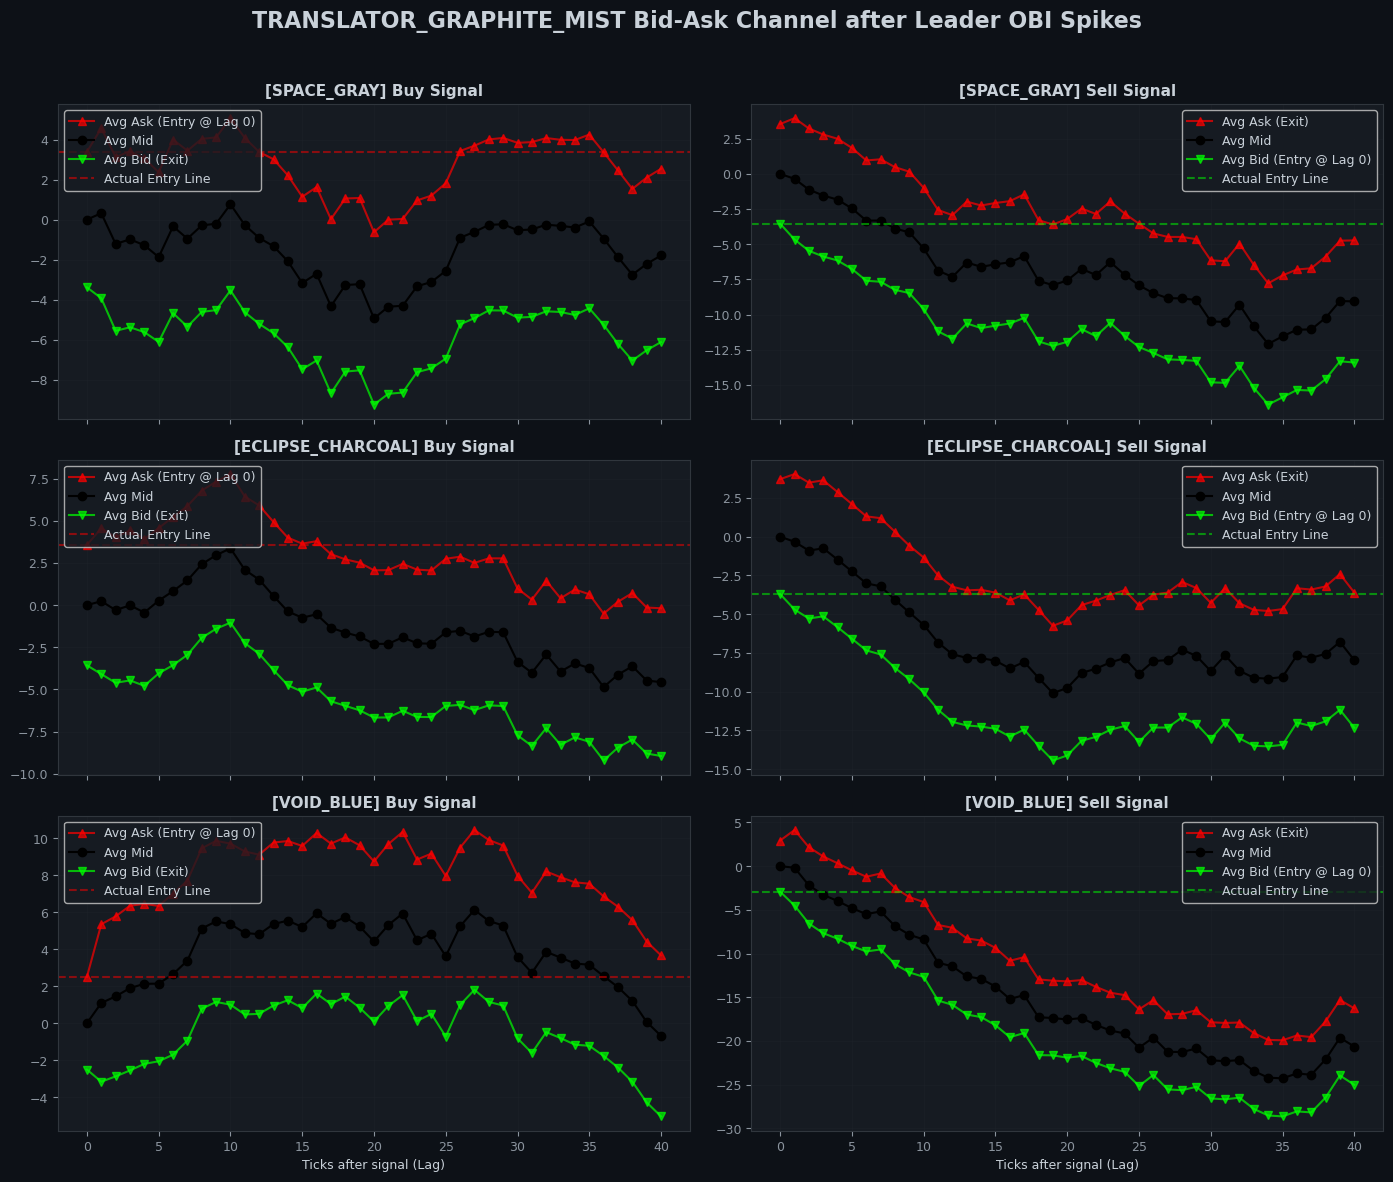

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Set data directory path
DATA_DIR = Path(r"d:\imc\ROUND5")

# Load data (Day 2)
prices = pd.read_csv(DATA_DIR / "prices_round_5_day_2.csv", sep=';')

# Set products of interest
leaders = ['TRANSLATOR_SPACE_GRAY', 'TRANSLATOR_ECLIPSE_CHARCOAL', 'TRANSLATOR_VOID_BLUE']
follower = 'TRANSLATOR_GRAPHITE_MIST'

# Extract and clean data
df_filtered = prices[prices['product'].isin(leaders + [follower])].copy()

# Compute OBI
df_filtered['bid_vol'] = df_filtered['bid_volume_1'].fillna(0)
df_filtered['ask_vol'] = df_filtered['ask_volume_1'].fillna(0)
df_filtered['vol_sum'] = (df_filtered['bid_vol'] + df_filtered['ask_vol']).replace(0, 1)
df_filtered['obi'] = (df_filtered['bid_vol'] - df_filtered['ask_vol']) / df_filtered['vol_sum']

# Build pivot table
pivot_obi = df_filtered[df_filtered['product'].isin(leaders)].pivot_table(index='timestamp', columns='product', values='obi').fillna(0)

# Extract follower price series
pivot_mid = df_filtered[df_filtered['product'] == follower].set_index('timestamp')['mid_price']
pivot_bid = df_filtered[df_filtered['product'] == follower].set_index('timestamp')['bid_price_1'].ffill()
pivot_ask = df_filtered[df_filtered['product'] == follower].set_index('timestamp')['ask_price_1'].ffill()

threshold = 0.5
MAX_LAG = 40

# Visualization: 3×2 grid (one row per leader, buy vs. sell)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12), sharex=True)
fig.suptitle(f"{follower} Bid-Ask Channel after Leader OBI Spikes", fontsize=16, fontweight='bold')

x_lags = np.arange(0, MAX_LAG + 1)

for i, leader in enumerate(leaders):
    buy_t = pivot_obi[pivot_obi[leader] >= threshold].index
    sell_t = pivot_obi[pivot_obi[leader] <= -threshold].index
    
    buy_mid, buy_bid, buy_ask = [], [], []
    sell_mid, sell_bid, sell_ask = [], [], []
    
    for lag in range(0, MAX_LAG + 1):
        # Normalize entry price at lag-0 to zero; compute per-tick price change
        mid_diff = pivot_mid.shift(-lag) - pivot_mid
        bid_diff = pivot_bid.shift(-lag) - pivot_mid
        ask_diff = pivot_ask.shift(-lag) - pivot_mid
        
        buy_mid.append(mid_diff.loc[mid_diff.index.intersection(buy_t)].mean())
        buy_bid.append(bid_diff.loc[bid_diff.index.intersection(buy_t)].mean())
        buy_ask.append(ask_diff.loc[ask_diff.index.intersection(buy_t)].mean())
        
        sell_mid.append(mid_diff.loc[mid_diff.index.intersection(sell_t)].mean())
        sell_bid.append(bid_diff.loc[bid_diff.index.intersection(sell_t)].mean())
        sell_ask.append(ask_diff.loc[ask_diff.index.intersection(sell_t)].mean())
    
    # ==========================
    # 1. Buy Signal Subplot (Left)
    # ==========================
    ax_b = axes[i, 0]
    ax_b.plot(x_lags, buy_ask, label='Avg Ask (Entry @ Lag 0)', color='red', marker='^', alpha=0.7)
    ax_b.plot(x_lags, buy_mid, label='Avg Mid', color='black', marker='o')
    ax_b.plot(x_lags, buy_bid, label='Avg Bid (Exit)', color='lime', marker='v', alpha=0.7)
    
    # Entry price reference line (dashed)
    entry_price = buy_ask[0] 
    ax_b.axhline(entry_price, color='red', linestyle='--', alpha=0.5, label='Actual Entry Line')
    
    ax_b.set_title(f"[{leader.split('_', 1)[1]}] Buy Signal", fontsize=11, fontweight='bold')
    ax_b.grid(True, alpha=0.3)
    ax_b.legend(fontsize=9, loc='upper left')
    
    # ==========================
    # 2. Sell Signal Subplot (Right)
    # ==========================
    ax_s = axes[i, 1]
    ax_s.plot(x_lags, sell_ask, label='Avg Ask (Exit)', color='red', marker='^', alpha=0.7)
    ax_s.plot(x_lags, sell_mid, label='Avg Mid', color='black', marker='o')
    ax_s.plot(x_lags, sell_bid, label='Avg Bid (Entry @ Lag 0)', color='lime', marker='v', alpha=0.7)
    
    # Entry price reference line (dashed)
    entry_price_s = sell_bid[0] 
    ax_s.axhline(entry_price_s, color='lime', linestyle='--', alpha=0.5, label='Actual Entry Line')
    
    ax_s.set_title(f"[{leader.split('_', 1)[1]}] Sell Signal", fontsize=11, fontweight='bold')
    ax_s.grid(True, alpha=0.3)
    ax_s.legend(fontsize=9, loc='upper right')

axes[-1, 0].set_xlabel("Ticks after signal (Lag)")
axes[-1, 1].set_xlabel("Ticks after signal (Lag)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#### SLEEP_POD: POLYESTER ↔ NYLON Bidirectional Lead-Lag

The most promising candidate identified during the search. SLEEP_POD had two variants (POLYESTER, NYLON) with high intra-group correlation.

Tested both directions: POLYESTER OBI → NYLON price, and NYLON OBI → POLYESTER price.

> **Finding (Day 2):** A weak but visible directional response appeared at 1–10 tick lags in the POLYESTER → NYLON direction. Buy signals (OBI ≥ 0.5) showed slight positive forward returns in NYLON over 5–10 ticks.
>
> ⚠️ **This is where anchoring bias became critical.** The organizer's lead-lag hint made this weak Day 2 signal feel like confirmation. The correct next step was OOS validation on Day 3/4. That step was skipped under time pressure — and this signal, combined with ad-hoc Z-score pair construction without cointegration testing, formed the basis of the final deployed strategy.
>
> **In the live environment, the strategy collapsed.** The Day 2 signal did not generalize.


=== OBI 임계값(±0.5) 돌파 후 N틱 누적 가격 변화(수익) 평균 (Day 2) ===

[Leader: SLEEP_POD_POLYESTER -> Follower: SLEEP_POD_NYLON]
 OBI >= 0.5 (매수) 1~10틱 평균 수익: [2.9, 3.21, 3.24, 5.26, 3.67, 4.25, 3.72, 3.47, 3.33, 4.26]
 OBI <= -0.5 (매도) 1~10틱 평균 수익: [-3.67, -3.41, -4.87, -3.98, -4.12, -5.36, -5.99, -6.11, -8.16, -9.38]

[Leader: SLEEP_POD_NYLON -> Follower: SLEEP_POD_POLYESTER]
 OBI >= 0.5 (매수) 1~10틱 평균 수익: [1.33, 1.39, 0.7, 0.12, 0.31, 1.24, 0.86, 0.69, 0.01, 0.52]
 OBI <= -0.5 (매도) 1~10틱 평균 수익: [-1.44, -1.29, -1.05, -0.38, -0.8, -0.19, -0.61, -0.48, 0.11, 0.24]


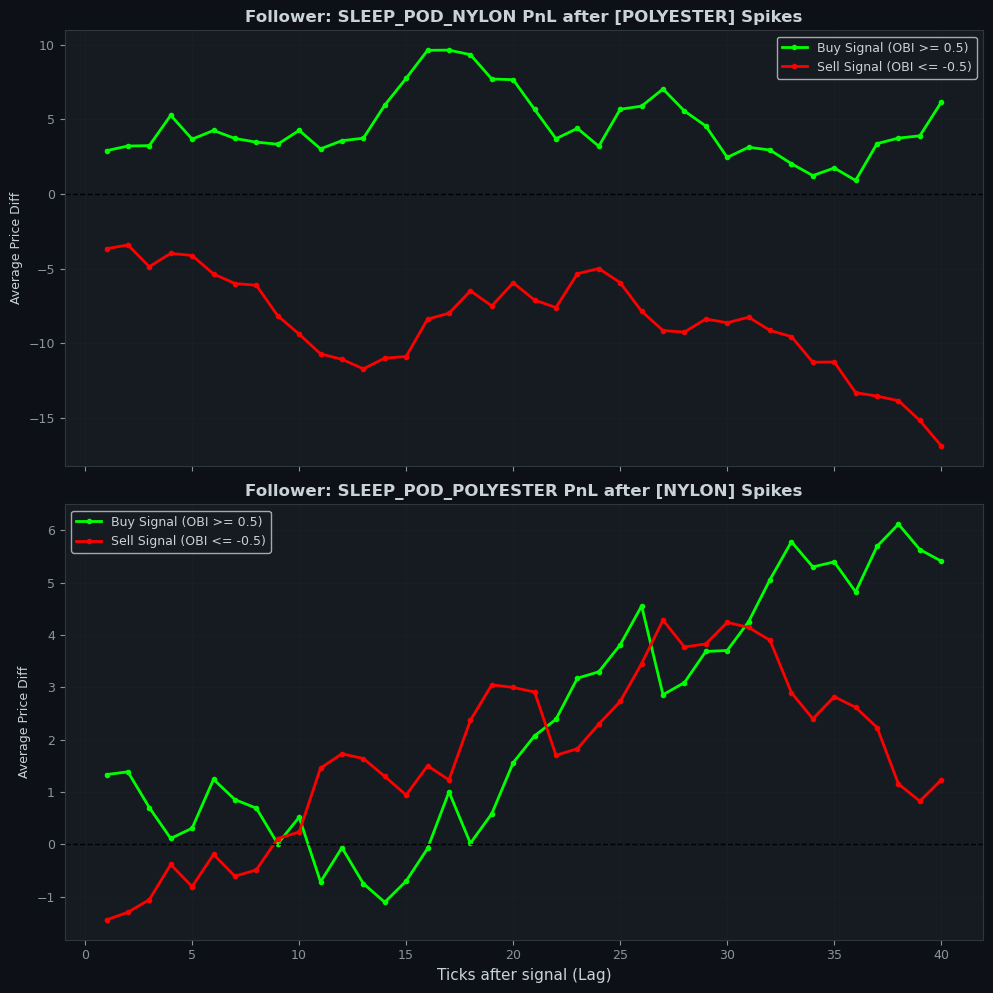

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Set data directory path
DATA_DIR = Path(r"d:\imc\ROUND5")

# Load data (Recommended: switch to day 3 or day 4 to test OOS generalization)
day = 2
prices = pd.read_csv(DATA_DIR / f"prices_round_5_day_{day}.csv", sep=';')

# Set pair direction for analysis (Leader → Follower)
pairs = [
    {'leader': 'SLEEP_POD_POLYESTER', 'follower': 'SLEEP_POD_NYLON'},
    {'leader': 'SLEEP_POD_NYLON', 'follower': 'SLEEP_POD_POLYESTER'}
]

threshold = 0.5
MAX_LAG = 40  # Extended to 40 ticks to see longer-horizon drift

# Visualization: 2 pair directions
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

print(f"=== Mean cumulative price change (N ticks) after OBI threshold ±{threshold} is crossed (Day {day}) ===")

for i, pair in enumerate(pairs):
    leader = pair['leader']
    follower = pair['follower']
    
    # Extract data
    df_filtered = prices[prices['product'].isin([leader, follower])].copy()
    
    # Compute OBI
    df_filtered['bid_vol'] = df_filtered['bid_volume_1'].fillna(0)
    df_filtered['ask_vol'] = df_filtered['ask_volume_1'].fillna(0)
    df_filtered['vol_sum'] = (df_filtered['bid_vol'] + df_filtered['ask_vol']).replace(0, 1)
    df_filtered['obi'] = (df_filtered['bid_vol'] - df_filtered['ask_vol']) / df_filtered['vol_sum']
    
    pivot_obi = df_filtered[df_filtered['product'] == leader].set_index('timestamp')['obi']
    pivot_price = df_filtered[df_filtered['product'] == follower].set_index('timestamp')['mid_price']
    
    # Signal trigger timestamps
    buy_times = pivot_obi[pivot_obi >= threshold].index
    sell_times = pivot_obi[pivot_obi <= -threshold].index
    
    buy_means = []
    sell_means = []
    
    for lag in range(1, MAX_LAG + 1):
        future_diff = pivot_price.shift(-lag) - pivot_price
        
        buy_diffs = future_diff.loc[future_diff.index.intersection(buy_times)].dropna()
        sell_diffs = future_diff.loc[future_diff.index.intersection(sell_times)].dropna()
        
        buy_means.append(buy_diffs.mean() if len(buy_diffs) > 0 else 0)
        sell_means.append(sell_diffs.mean() if len(sell_diffs) > 0 else 0)
        
    print(f"\n[Leader: {leader} -> Follower: {follower}]")
    print(f" OBI >= {threshold} (buy) mean 1–10 tick profit: {[round(x, 2) for x in buy_means[:10]]}")
    print(f" OBI <= -{threshold} (sell) mean 1–10 tick profit: {[round(x, 2) for x in sell_means[:10]]}")
    
    # Line chart visualization
    ax = axes[i]
    x_lags = np.arange(1, MAX_LAG + 1)
    
    ax.plot(x_lags, buy_means, marker='.', color='lime', linewidth=2, label=f'Buy Signal (OBI >= {threshold})')
    ax.plot(x_lags, sell_means, marker='.', color='red', linewidth=2, label=f'Sell Signal (OBI <= -{threshold})')
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    
    ax.set_title(f"Follower: {follower} PnL after [{leader.split('_', 2)[-1]}] Spikes", fontsize=12, fontweight='bold')
    ax.set_ylabel("Average Price Diff")
    ax.set_xticks(np.arange(0, MAX_LAG + 1, 5))
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Ticks after signal (Lag)", fontsize=11)
plt.tight_layout()
plt.show()


#### SLEEP_POD: Extended Lag Analysis (Mid / Ask / Bid)

Extending the lag window to 40 ticks, decomposing by actual entry price (ask for buys, bid for sells) vs mid-price drift.

> **Final finding:** Even at 40 ticks, the profit zone (area between entry price and future bid/ask) was minimal or negative. The signal that looked directional on Day 2 at mid-price level did not survive when actual transaction costs (spread) were applied. The entry line and the future bid/ask curves converged to near-zero edge.
>
> This is the quantitative record of why the strategy failed. Not because the idea was wrong in theory — lead-lag in correlated asset pairs is a legitimate microstructure phenomenon. But because the evidence for it here was too thin, too short, and never validated out-of-sample.

---

## Summary: What This Notebook Shows

| Phase | What was tested | Finding |
|-------|----------------|---------|
| EDA | Spread, OBI, correlation universe | High intra-group co-movement, weak cross-group signal |
| Sector indices | Cross-sector lead-lag | No consistent timing pattern |
| SNACKPACK pairs | OBI lead-lag, PCA basket | Negative edge after spread costs |
| TRANSLATOR pairs | OBI lead-lag | Signal indistinguishable from noise |
| SLEEP_POD pairs | OBI lead-lag (POLYESTER ↔ NYLON) | Weak Day 2 signal, not validated OOS — this became the deployed strategy |

**The failure was not finding the wrong asset. The failure was treating a Day 2 in-sample observation as a robust signal without OOS validation.**


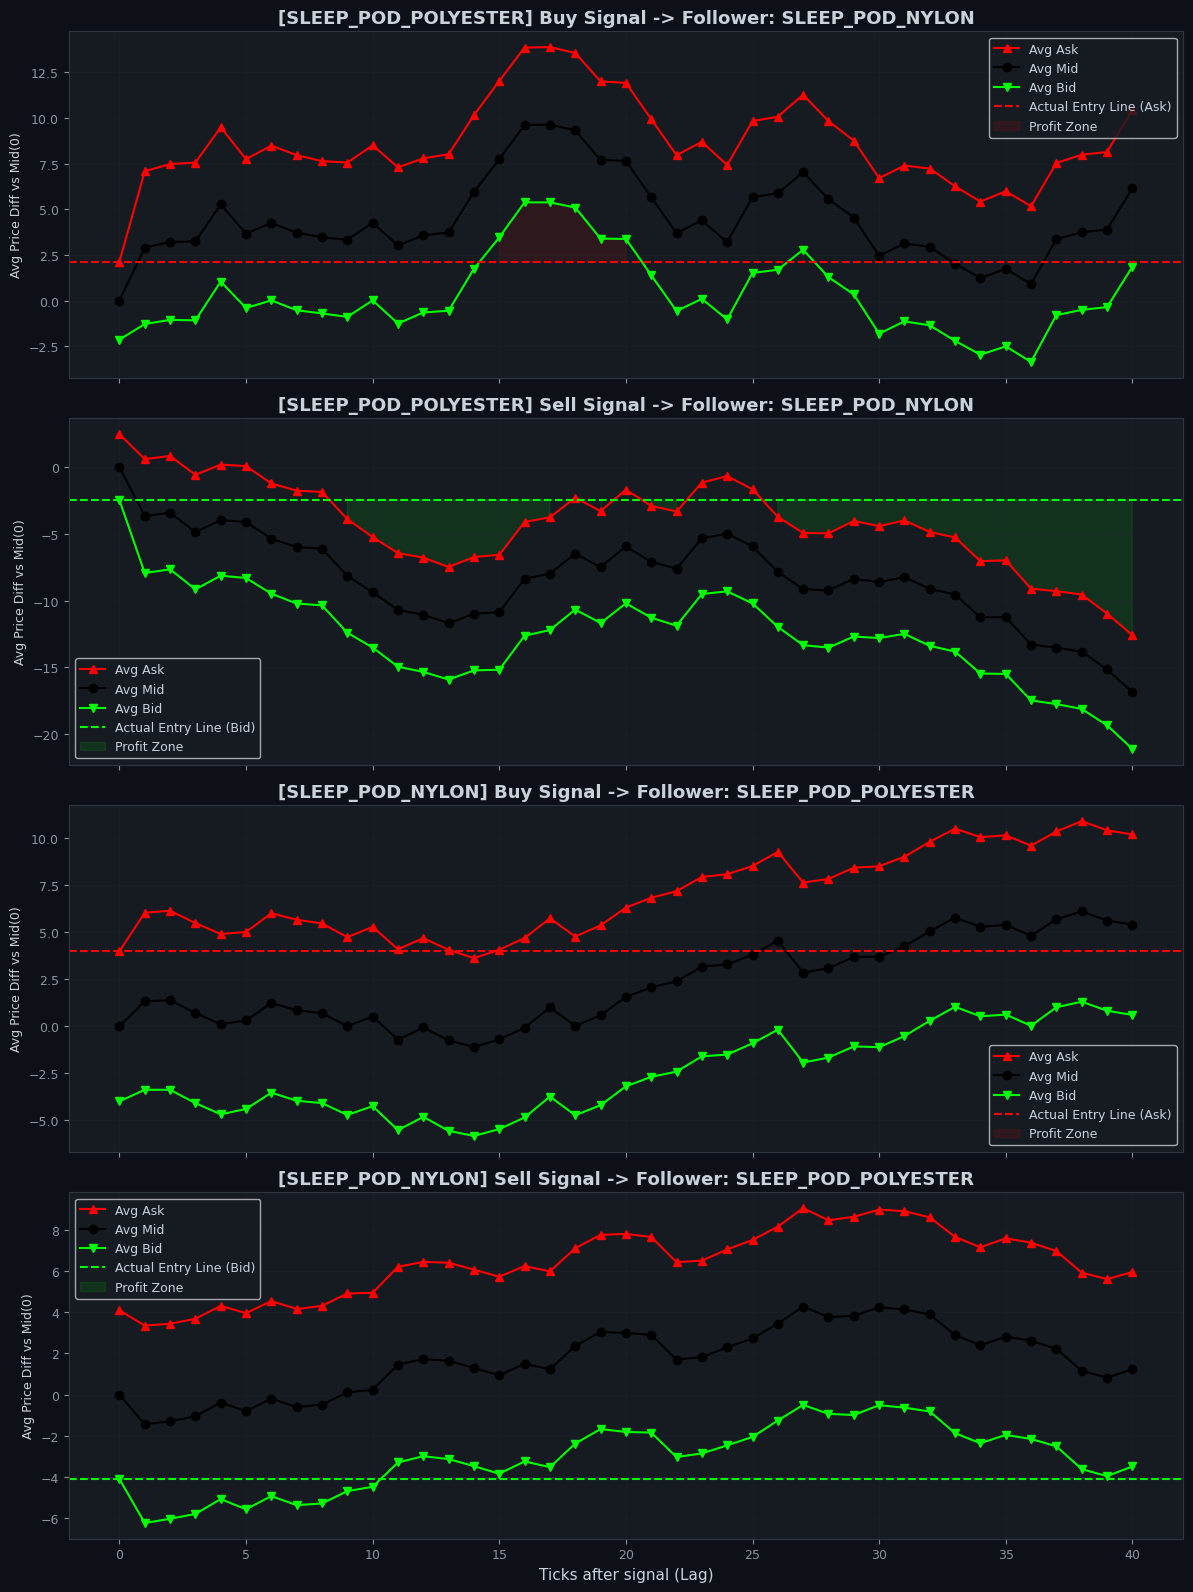

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Set data directory path
DATA_DIR = Path(r"d:\imc\ROUND5")

# Load data (test with days 2, 3, 4 to verify out-of-sample stability)
day = 2
prices = pd.read_csv(DATA_DIR / f"prices_round_5_day_{day}.csv", sep=';')

# Set pair directions for analysis
pairs = [
    {'leader': 'SLEEP_POD_POLYESTER', 'follower': 'SLEEP_POD_NYLON'},
    {'leader': 'SLEEP_POD_NYLON', 'follower': 'SLEEP_POD_POLYESTER'}
]

threshold = 0.5
MAX_LAG = 40

# Visualization: 2 pairs × 2 directions = 4 charts total
fig, axes = plt.subplots(nrows=len(pairs) * 2, ncols=1, figsize=(12, 16), sharex=True)

for i, pair in enumerate(pairs):
    leader = pair['leader']
    follower = pair['follower']
    
    df_filtered = prices[prices['product'].isin([leader, follower])].copy()
    
    # Leader Compute OBI
    leader_df = df_filtered[df_filtered['product'] == leader].set_index('timestamp')
    leader_df['bid_vol'] = leader_df['bid_volume_1'].fillna(0)
    leader_df['ask_vol'] = leader_df['ask_volume_1'].fillna(0)
    leader_df['vol_sum'] = (leader_df['bid_vol'] + leader_df['ask_vol']).replace(0, 1)
    leader_obi = (leader_df['bid_vol'] - leader_df['ask_vol']) / leader_df['vol_sum']
    
    # Extract Follower price series
    follower_df = df_filtered[df_filtered['product'] == follower].set_index('timestamp')
    f_mid = follower_df['mid_price']
    f_ask = follower_df['ask_price_1']
    f_bid = follower_df['bid_price_1']
    
    # Signal trigger timestamps
    buy_times = leader_obi[leader_obi >= threshold].index
    sell_times = leader_obi[leader_obi <= -threshold].index
    
    for sig_idx, (sig_name, sig_times) in enumerate([('Buy', buy_times), ('Sell', sell_times)]):
        ax = axes[i * 2 + sig_idx]
        
        valid_times = f_mid.index.intersection(sig_times)
        if len(valid_times) == 0:
            ax.set_title(f"[{leader}] {sig_name} Signal -> {follower} (No Data)")
            continue
            
        mid_diffs = []
        ask_diffs = []
        bid_diffs = []
        
        for lag in range(0, MAX_LAG + 1):
            # Normalize to mid price at entry (lag 0)
            ref_mid = f_mid.loc[valid_times]
            
            # Price at t+lag
            future_times = valid_times + lag * 100
            
            # Filter to timestamps that exist in data
            valid_mask = future_times.isin(f_mid.index)
            v_times = valid_times[valid_mask]
            f_times = future_times[valid_mask]
            
            if len(v_times) == 0:
                mid_diffs.append(np.nan); ask_diffs.append(np.nan); bid_diffs.append(np.nan)
                continue
                
            r_mid = f_mid.loc[v_times].values
            lag_mid = f_mid.loc[f_times].values
            lag_ask = f_ask.loc[f_times].values
            lag_bid = f_bid.loc[f_times].values
            
            mid_diffs.append(np.mean(lag_mid - r_mid))
            ask_diffs.append(np.mean(lag_ask - r_mid))
            bid_diffs.append(np.mean(lag_bid - r_mid))
            
        x_lags = np.arange(0, MAX_LAG + 1)
        
        # Draw lines: red=Ask, black=Mid, green=Bid
        ax.plot(x_lags, ask_diffs, marker='^', color='red', label='Avg Ask')
        ax.plot(x_lags, mid_diffs, marker='o', color='black', label='Avg Mid')
        ax.plot(x_lags, bid_diffs, marker='v', color='lime', label='Avg Bid')
        
        # Entry price by signal: Buy enters at Ask; Sell enters at Bid
        if sig_name == 'Sell':
            entry_line = bid_diffs[0]
            ax.axhline(entry_line, color='lime', linestyle='--', label=f'Actual Entry Line (Bid)')
            ax.fill_between(x_lags, ask_diffs, entry_line, where=(np.array(ask_diffs) < entry_line), color='lime', alpha=0.1, label='Profit Zone')
        else:
            entry_line = ask_diffs[0]
            ax.axhline(entry_line, color='red', linestyle='--', label=f'Actual Entry Line (Ask)')
            ax.fill_between(x_lags, bid_diffs, entry_line, where=(np.array(bid_diffs) > entry_line), color='red', alpha=0.1, label='Profit Zone')
            
        ax.set_title(f"[{leader}] {sig_name} Signal -> Follower: {follower}", fontsize=13, fontweight='bold')
        ax.set_ylabel("Avg Price Diff vs Mid(0)")
        ax.set_xticks(np.arange(0, MAX_LAG + 1, 5))
        ax.legend()
        ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Ticks after signal (Lag)", fontsize=11)
plt.tight_layout()
plt.show()
